In [ ]:
using SparseArrays
using LinearAlgebra
using Arpack
using Statistics
using Random
using DelimitedFiles
using NPZ
using ExpmV
using Dates

Random.seed!(Dates.now().instant.periods.value)

function random_product_state(L::Int)
    ψ = nothing
    for i in 1:L
        θ1, θ2 = rand() * π, rand() * π
        ϕ1, ϕ2 = rand() * 2π, rand() * 2π
        c1 = cos(θ1 / 2)
        c2 = exp(im * ϕ1) * sin(θ1 / 2) * sin(θ2 / 2)
        c3 = exp(im * ϕ2) * sin(θ1 / 2) * cos(θ2 / 2)
        site_state = [c1, c2, c3]
        ψ = i == 1 ? site_state : kron(ψ, site_state)
    end
    return ψ / norm(ψ)
end

function superposition_state(L::Int)
    # single-site state (|0> + |1> + |2>) / sqrt(3)
    φ = ones(ComplexF64, 3) / sqrt(3)

    ψ = φ
    for _ in 2:L
        ψ = kron(ψ, φ)
    end

    return ψ
end

# ---------------------------------------------------------
# Haar-random unitary (3×3), converted to sparse
# ---------------------------------------------------------
function haar_unitary_sparse(n::Int)
    A = randn(ComplexF64, n, n)
    Q, R = qr(A)
    phases = Diagonal(R) ./ abs.(Diagonal(R))
    return sparse(Q * Diagonal(phases))
end

# ---------------------------------------------------------
# Build 9×9 Z3-conserving Haar unitary as sparse blockdiag
#
# Basis ordering (Z3 sectors):
#   charge 0: 00, 12, 21
#   charge 1: 01, 10, 22
#   charge 2: 02, 20, 11
#
# So U_z3 is blockdiag(U0, U1, U2)
# ---------------------------------------------------------
function z3_haar()
    U0 = haar_unitary_sparse(3)
    U1 = haar_unitary_sparse(3)
    U2 = haar_unitary_sparse(3)
    return blockdiag(U0, U1, U2)  # built-in sparse blockdiag
end

# ---------------------------------------------------------
# Sparse permutation matrix: Z3 basis → standard lexicographic basis
#
# Z3 basis order:
#   ["00","12","21",  "01","10","22",  "02","20","11"]
#
# Standard basis order:
#   ["00","01","02",  "10","11","12",  "20","21","22"]
# ---------------------------------------------------------
function permutation_matrix_sparse()
    z3  = ["00","12","21","01","10","22","02","20","11"]
    std = ["00","01","02","10","11","12","20","21","22"]

    rows = Int[]
    cols = Int[]
    vals = ComplexF64[]

    for (i, state) in enumerate(z3)
        j = findfirst(==(state), std)
        push!(rows, j)
        push!(cols, i)
        push!(vals, 1.0 + 0im)
    end

    return sparse(rows, cols, vals, 9, 9)
end

# ---------------------------------------------------------
# Apply sparse basis change: U_std = P * U_z3 * P'
# ---------------------------------------------------------
function transform(U_z3)
    P = permutation_matrix_sparse()
    return P * U_z3 * P'
end

function odd_layer(L::Int)
    U = transform(z3_haar())
    for _ in 3:2:L-1
        U = kron(U, transform(z3_haar()))
    end
    return U
end

function even_layer(L::Int)
    id = sparse(ComplexF64[1 0 0; 0 1 0; 0 0 1])
    U = id
    for _ in 2:2:L-1
        U = kron(U, transform(z3_haar()))
    end
    return kron(U, id)
end

function time_evolution(ψ::Vector{ComplexF64}, L)

    U_odd  = odd_layer(L)
    U_even = even_layer(L)

    ψ_odd = U_odd * ψ
    ψ_even = U_even * ψ_odd

    return normalize!(ψ_even)
end

function entropy_vn(ψ::Vector{<:Complex}, L::Int, subsystem::AbstractArray{Int})
    cut = length(subsystem)
    dimA = 3^cut
    dimB = 3^(L - cut)
    
    ψ_matrix = reshape(ψ, (dimA, dimB))
    svals = svdvals(ψ_matrix)

    
    S = 0.0
    
    for s in svals
        if s > 1e-15
            p = abs2(s)
            S -= p * log(p)
        end
    end
    return S
end

function get_z3_operators()
    id = sparse(ComplexF64[1 0 0; 0 1 0; 0 0 1])
    τ = sparse(ComplexF64[1 0 0; 0 exp(2im * pi / 3) 0; 0 0 exp(4im * pi / 3)]) ## τ in Romain's paper

    return id, τ
end

function build_term(operators::Vector{<:SparseMatrixCSC}) #
    term = operators[1]
    for j in 2:length(operators)
        term = kron(term, operators[j])
    end
    return term
end

function create_local_q_operator(L::Int, site::Int)
    id, τ = get_z3_operators()
    ops = fill(id, L)
    ops[site] = (im / sqrt(3)) * (τ' - τ)
    return build_term(ops)
end

function charge_expectation(ψ::Vector{ComplexF64}, L::Int)
    ω = cis(2pi / 3)   
    expU = zero(ComplexF64)

    for (idx, amp) in enumerate(ψ)
        n = idx - 1
        q = 0
        @inbounds for _ in 1:L
            q += n % 3
            n ÷= 3
        end
        expU += abs2(amp) * ω^q
    end

    return expU
end

function shannon_entropy(ψ::Vector{ComplexF64}, L::Int)
    # Probabilities for the three Z₃ charge sectors
    p0 = 0.0
    p1 = 0.0
    p2 = 0.0

    for (idx, amp) in enumerate(ψ)
        # Decode basis index -> total charge mod 3
        n = idx - 1
        q = 0
        for _ in 1:L
            q += n % 3
            n ÷= 3
        end
        q %= 3

        # Born probability
        w = abs2(amp)

        if q == 0
            p0 += w
        elseif q == 1
            p1 += w
        else
            p2 += w
        end
    end

    # Shannon entropy
    S = 0.0
    if p0 > 1e-15; S -= p0 * log(p0); end
    if p1 > 1e-15; S -= p1 * log(p1); end
    if p2 > 1e-15; S -= p2 * log(p2); end

    return S
end


function Entropy_t(L::Int, T::Float64, dt::Float64, p::Float64, shot::Int)
    
    # Initialize state
    #s_t = random_product_state(L)
    s_t = superposition_state(L)
    
    # Time evolution

    ω = exp(2im * pi / 3)
    
    # Build a list of single-site Q operators for measurement
    Ql = [create_local_q_operator(L, i) for i in 1:L]
    
    # Initialize lists to store results
    #S_list = Float64[]
    SE_list = Float64[]

    steps = Int(floor(T / dt))

    for _ in 1:steps
        
        # Record half-chain entropy
        #push!(S_list, entropy_vn(s_t, L, 1:L÷2))
        push!(SE_list, shannon_entropy(s_t, L))

        # Time evolution
        s_t = time_evolution(s_t, L)

        # Measurements
        if p != 0
            for l in 2:L-1 ## avoid edges
                if rand() < p ## edit this
                    p_m_zero  = real(s_t' * s_t) - real(s_t' * Ql[l] * Ql[l] * s_t)
                    p_m_one = 0.5 * real(s_t' * Ql[l] * s_t) + 0.5 * real(s_t' * Ql[l] * Ql[l] * s_t)
                    x1 = rand()
                    if x1 < p_m_zero
                        s_t = (s_t - (Ql[l] * Ql[l] * s_t)) / sqrt(p_m_zero)
                    elseif p_m_zero ≤ x1 < (p_m_one + p_m_zero)
                        s_t = 0.5 * (Ql[l] * s_t + Ql[l] * Ql[l] * s_t) / sqrt(p_m_one)
                    else
                        s_t = 0.5 * ((Ql[l] * Ql[l] * s_t) - s_t) / sqrt(1 - p_m_zero - p_m_one)
                    end
                end
            end
        end
    end

    """
    # Data storage for Jed's Mac
    base_folder = "/Users/uditvarma/Project_Data/z3-haar" 

    today_date = Dates.format(Dates.today(), "yyyy-mm-dd")
    parent_dir = dirname(base_folder)
    folder_name = basename(base_folder) * "_" * today_date
    folder = joinpath(parent_dir, folder_name)
    mkpath(folder)    
    filename_entropy = joinpath(folder, "L$(L),T$(T),dt$(dt),p$(p),dirQ,s$(shot)_hc.npy")
    npzwrite(filename_entropy, S_list)
    """

    """
    # Data storage for Udit's Mac
    base_folder = "/Users/dirac/Projects-Data/z3-haar-data" 

    today_date = Dates.format(Dates.today(), "yyyy-mm-dd")
    parent_dir = dirname(base_folder)
    folder_name = basename(base_folder) * "_" * today_date
    folder = joinpath(parent_dir, folder_name)
    mkpath(folder)    
    filename_entropy = joinpath(folder, "L$(L),T$(T),dt$(dt),p$(p),dirQ,s$(shot)_hc.npy")
    npzwrite(filename_entropy, S_list)
    """
    
    
    # Data storage for cluster
    filename_entropy = "L$(L),T$(T),dt$(dt),p$(p),dirQ,s$(shot)_se.npy"
    npzwrite(filename_entropy, SE_list)
    
    
    #println("Shannon entropy: ", shannon_entropy(s_t, L))

    return SE_list
end

Entropy_t (generic function with 1 method)

In [13]:
for p in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] 
    Entropy_t(8, 80.0, 1.0, p, 9)
end

Shannon entropy: 1.0986122886681098
Shannon entropy: 1.0967126046452922
Shannon entropy: 0.8419272409845808
Shannon entropy: 0.20357127619794932
Shannon entropy: 0.5765917756361165
Shannon entropy: 0.12610556220865113
Shannon entropy: 0.7915288269972179
Shannon entropy: 0.1922007116804223
Shannon entropy: 0.0002405629227781242
Shannon entropy: 5.606076070492118e-6
Shannon entropy: 0.07447655023439195


In [ ]:
function total_q_product(L::Int)
    id, τ = get_z3_operators()
    op = sparsezero(ComplexF64, 3^L, 3^L)
    for i in 1:L
        op = kron

In [4]:
id, τ = get_z3_operators()
(im / sqrt(3)) * (τ' - τ)

3×3 SparseMatrixCSC{ComplexF64, Int64} with 2 stored entries:
     ⋅          ⋅           ⋅    
     ⋅      1.0+0.0im       ⋅    
     ⋅          ⋅      -1.0+0.0im

In [5]:
function global_charge_exp_cheeky(ψ::Vector{ComplexF64}, L::Int)
    ω = exp(2im * pi / 3)
    expU = 0.0 + 0.0im

    for (idx, amp) in enumerate(ψ)
        # Convert index to base-3 digits (site occupations)
        n = idx - 1
        charge = 0
        for _ in 1:L
            charge += n % 3
            n ÷= 3
        end
        expU += abs2(amp) * ω^charge
    end

    varU = 1.0 - abs2(expU)
    return expU, real(varU)
end

global_charge_exp_cheeky (generic function with 1 method)

In [14]:
psi = [1.0+0.0im, 0.0+0.0im, 0.0+0.0im]

3-element Vector{ComplexF64}:
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im

In [15]:
global_charge_exp_cheeky(psi, 1)

(1.0 + 0.0im, 0.0)

In [3]:
Entropy_t(8, 80.0, 1.0, 0.0, 1)

80-element Vector{ComplexF64}:
 -0.013699567088907901 - 0.054060593655172184im
 -0.013699567088907986 - 0.05406059365517216im
 -0.013699567088908154 - 0.054060593655172295im
 -0.013699567088908035 - 0.054060593655172046im
 -0.013699567088908049 - 0.05406059365517192im
 -0.013699567088908142 - 0.05406059365517209im
 -0.013699567088908043 - 0.0540605936551719im
  -0.01369956708890807 - 0.05406059365517219im
 -0.013699567088908104 - 0.054060593655172025im
 -0.013699567088908082 - 0.05406059365517239im
                       ⋮
  -0.01369956708890814 - 0.05406059365517241im
 -0.013699567088908066 - 0.05406059365517221im
 -0.013699567088908142 - 0.0540605936551722im
  -0.01369956708890817 - 0.05406059365517208im
 -0.013699567088908167 - 0.05406059365517249im
 -0.013699567088908095 - 0.054060593655172094im
 -0.013699567088908128 - 0.0540605936551724im
  -0.01369956708890806 - 0.054060593655172004im
 -0.013699567088908203 - 0.054060593655172504im

Jan 29 - Optimizing the code

In [3]:
using LinearAlgebra

In [4]:
function random_product_state(L::Int)
    dim = 3^L
    ψ = Vector{ComplexF64}(undef, dim)

    # generate local states
    locals = Vector{NTuple{3,ComplexF64}}(undef, L)
    for i in 1:L
        θ1, θ2 = rand() * π, rand() * π
        ϕ1, ϕ2 = rand() * 2π, rand() * 2π

        locals[i] = (
            cos(θ1 / 2),
            exp(im * ϕ1) * sin(θ1 / 2) * sin(θ2 / 2),
            exp(im * ϕ2) * sin(θ1 / 2) * cos(θ2 / 2)
        )
    end

    # fill ψ using base-3 indexing
    for idx in 0:dim-1
        x = idx
        amp = one(ComplexF64)
        for i in 1:L
            s = (x % 3) + 1
            amp *= locals[i][s]
            x ÷= 3
        end
        ψ[idx + 1] = amp
    end

    normalize!(ψ)
    return ψ
end

random_product_state (generic function with 1 method)

In [7]:
random_product_state(2)

9-element Vector{ComplexF64}:
    0.6468750349439875 + 0.0im
 -0.018738441179576973 - 0.183338637423011im
   0.02860801013517444 + 0.023981687232352052im
   0.16780504129827228 + 5.701239018864596e-5im
 -0.004844756951150714 - 0.04756129744645566im
  0.007419054391703378 + 0.006223580769061572im
   -0.6764269921614444 - 0.13389088193117427im
 -0.018353134392888323 + 0.19559281567502387im
 -0.024951188594131705 - 0.0309985873400837im

In [16]:
function superposition_state(L::Int)
    dim = 3^L
    fill(ComplexF64(1 / sqrt(dim)), dim)
end

superposition_state (generic function with 1 method)

In [20]:
psi = superposition_state(12)

531441-element Vector{ComplexF64}:
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
                       ⋮
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im
 0.0013717421124828531 + 0.0im

In [10]:
function superposition_state(L::Int)
    # single-site state (|0> + |1> + |2>) / sqrt(3)
    φ = ones(ComplexF64, 3) / sqrt(3)

    ψ = φ
    for _ in 2:L
        ψ = kron(ψ, φ)
    end

    return ψ
end

superposition_state (generic function with 1 method)

In [11]:
superposition_state(3)

27-element Vector{ComplexF64}:
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
                     ⋮
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im
 0.19245008972987535 + 0.0im

In [13]:
function permutation_matrix()
    z3  = ["00","12","21","01","10","22","02","20","11"]
    std = ["00","01","02","10","11","12","20","21","22"]

    P = zeros(ComplexF64, 9, 9)
    for (i, s) in enumerate(z3)
        j = findfirst(==(s), std)
        P[j, i] = 1
    end
    return P
end

permutation_matrix (generic function with 1 method)

In [14]:
permutation_matrix()

9×9 Matrix{ComplexF64}:
 1.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     1.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  1.0+0.0im
 0.0+0.0im  1.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  1.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im

In [15]:
using LinearAlgebra

function calculate_entropy(psi::AbstractVector, L::Integer, subsystem_sites::AbstractVector{<:Integer}; 
    d::Integer=3)
    # Check if vector size matches the physical dimensions
    if length(psi) != d^L
        error("Dimension mismatch: Vector length $(length(psi)) does not match d^L ($d^$L = $(d^L))")
    end

    # 1. Reshape vector into a tensor with L indices of dimension d
    # usage of Tuple(fill(d, L)) ensures type stability for reshape
    psi_tensor = reshape(psi, ntuple(_ -> d, L))

    # 2. Identify environment sites
    # Using a Set for 'subsystem_sites' makes the lookup O(1) instead of O(N)
    sub_set = Set(subsystem_sites)
    environment_sites = [i for i in 1:L if i ∉ sub_set]
    
    # 3. Permute dimensions to group subsystem sites at the front
    permute_order = vcat(subsystem_sites, environment_sites)
    psi_permuted = permutedims(psi_tensor, permute_order)

    # 4. Reshape into a Matrix (dim_subsystem x dim_environment)
    dim_subsystem = d^length(subsystem_sites)
    dim_environment = d^length(environment_sites)
    psi_matrix = reshape(psi_permuted, dim_subsystem, dim_environment)

    # 5. Compute Singular Values (SVD)
    # svdvals is much faster than svd() because it doesn't compute U and V vectors
    s = svdvals(psi_matrix)

    # 6. Compute Entropy
    s_squared = s.^2
    
    # Normalize here instead of normalizing 'psi' at the start (saves 2 allocations)
    total_prob = sum(s_squared)
    s_squared ./= total_prob

    # Filter non-zero values to avoid log(0)
    # Using a slightly higher tolerance for stability
    filter!(x -> x > 1e-15, s_squared)
    
    entropy = -sum(s_squared .* log.(s_squared))

    return entropy
end

calculate_entropy (generic function with 1 method)

In [24]:
psi = ghz(12)

531441-element Vector{ComplexF64}:
 0.5773502691896258 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                    ⋮
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
 0.5773502691896258 + 0.0im

In [25]:
calculate_entropy(psi, 12, 1:6)

1.0986122886681096

In [26]:
log(3)

1.0986122886681098

In [22]:
function ghz(L::Int; d::Int=3)
    # Total Hilbert space dimension
    dim_total = d^L
    
    # Initialize the state vector with zeros
    ψ = zeros(ComplexF64, dim_total)
    
    # We want to populate the states |00...0>, |11...1>, ... |d-1...d-1>.
    # In a flattened vector, these indices are perfectly spaced apart.
    # The step size (stride) is (d^L - 1) / (d - 1).
    stride = (dim_total - 1) ÷ (d - 1)
    
    # Normalization factor
    norm_factor = 1.0 / sqrt(d)
    
    # Fill the specific indices
    for k in 0:(d-1)
        # 1-based indexing: start at 1, add k steps
        idx = 1 + k * stride
        ψ[idx] = norm_factor
    end

    return ψ
end

ghz (generic function with 1 method)

Starting Simulation...
Threads available: 1
Simulating L = 6...
........... Done.
Simulating L = 8...
........... Done.
Simulating L = 10...
........... Done.


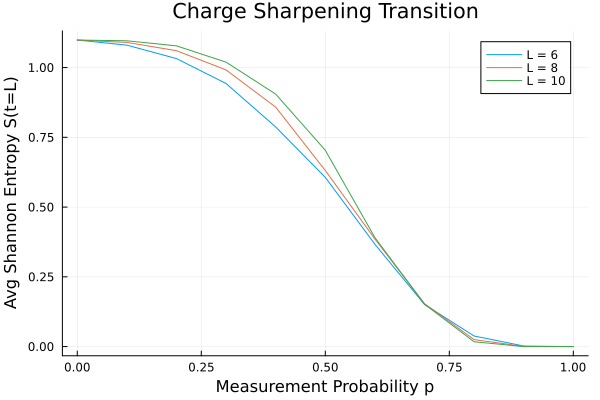

In [29]:
using LinearAlgebra
using Random
using StatsBase
using Plots

# ==========================================
# 1. CORE SIMULATION FUNCTIONS
# ==========================================

function construct_charge_conserving_gate()
    # Helper to generate 3x3 Haar random unitary
    function haar_3x3()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        d = diag(R)
        return Q * Diagonal(d ./ abs.(d))
    end

    U0, U1, U2 = haar_3x3(), haar_3x3(), haar_3x3()
    U = zeros(ComplexF64, 9, 9)
    
    # Indices mapping to Charge 0, 1, 2 sectors (see previous explanation)
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    
    U[idx0, idx0] = U0
    U[idx1, idx1] = U1
    U[idx2, idx2] = U2
    return U
end

function apply_gate!(psi, U_gate, site, L)
    dim_L = 3^(site - 1)
    dim_R = 3^(L - site - 1)
    # Reshape: (Left, Site1, Site2, Right) -> Permute -> (Site1, Site2, Left, Right)
    psi_t = permutedims(reshape(psi, dim_L, 3, 3, dim_R), (2, 3, 1, 4))
    # Matrix multiply: (9 x Env)
    psi_new = U_gate * reshape(psi_t, 9, :)
    # Reshape back: (Site1, Site2, Left, Right) -> Permute -> (Left, Site1, Site2, Right)
    psi[:] = reshape(permutedims(reshape(psi_new, 3, 3, dim_L, dim_R), (3, 1, 2, 4)), :)
end

function perform_measurements!(psi, L, p)
    for site in 1:L
        if rand() < p
            dim_L, dim_R = 3^(site-1), 3^(L-site)
            psi_t = reshape(psi, dim_L, 3, dim_R)
            
            # Calc probabilities for |0>, |1>, |2>
            probs = [sum(abs2, psi_t[:, s, :]) for s in 1:3]
            
            if sum(probs) > 1e-12
                outcome = sample(1:3, Weights(probs))
                norm_fac = 1.0 / sqrt(probs[outcome])
                
                # Project and Normalize
                for s in 1:3
                    if s != outcome
                        psi_t[:, s, :] .= 0
                    else
                        psi_t[:, s, :] .*= norm_fac
                    end
                end
            end
            psi[:] = psi_t
        end
    end
end

function get_final_entropy(psi, L)
    # Calculate probabilities of Total Charge Mod 3
    probs_charge = zeros(3)
    for i in 0:(3^L - 1)
        amp = abs2(psi[i+1])
        if amp > 1e-15
            # Calculate sum of digits in base 3 efficiently
            val, total_charge = i, 0
            for _ in 1:L
                total_charge += val % 3
                val ÷= 3
            end
            probs_charge[(total_charge % 3) + 1] += amp
        end
    end
    # Shannon Entropy
    return -sum(p -> p > 1e-15 ? p * log(p) : 0.0, probs_charge)
end

# ==========================================
# 2. EXPERIMENT RUNNER
# ==========================================

function run_single_realization(L, p)
    # Initial State: Equal superposition normalized
    psi = ones(ComplexF64, 3^L)
    psi ./= norm(psi)
    
    # Evolve for t = 1 to L
    for t in 1:L
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi, construct_charge_conserving_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-1)
            apply_gate!(psi, construct_charge_conserving_gate(), x, L)
        end
        # Measurements
        perform_measurements!(psi, L, p)
    end
    
    return get_final_entropy(psi, L)
end

function run_experiment_sweep()
    # --- PARAMETERS ---
    L_values = [6, 8, 10]          # System sizes
    p_values = 0.0:0.1:1.0        # Measurement probabilities
    n_realizations = 500            # Number of runs per point
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        println("Simulating L = $L...")
        avg_entropies = Float64[]
        
        for p in p_values
            # Run realizations in parallel for speed
            batch_entropies = zeros(n_realizations)
            
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            
            push!(avg_entropies, mean(batch_entropies))
            print(".") # Progress bar dot
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. PLOTTING
# ==========================================

p_vals, data = run_experiment_sweep()

# Create the plot
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Avg Shannon Entropy S(t=L)",
    title = "Charge Sharpening Transition",
    legend = :topright,
    lw = 2,
    marker = :circle
)

for (L, entropies) in sort(collect(data))
    plot!(plt, p_vals, entropies, label = "L = $L")
end

display(plt)
# savefig("charge_sharpening.png") # Uncomment to save

In [ ]:
using LinearAlgebra
using Random
using StatsBase
using Plots

# ==========================================
# 1. CORE SIMULATION FUNCTIONS
# ==========================================

function construct_charge_conserving_gate()
    # Helper to generate 3x3 Haar random unitary
    function haar_3x3()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        d = diag(R)
        return Q * Diagonal(d ./ abs.(d))
    end

    U0, U1, U2 = haar_3x3(), haar_3x3(), haar_3x3()
    U = zeros(ComplexF64, 9, 9)
    
    # Indices mapping to Charge 0, 1, 2 sectors (see previous explanation)
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    
    U[idx0, idx0] = U0
    U[idx1, idx1] = U1
    U[idx2, idx2] = U2
    return U
end

function apply_gate!(psi, U_gate, site, L)
    dim_L = 3^(site - 1)
    dim_R = 3^(L - site - 1)
    # Reshape: (Left, Site1, Site2, Right) -> Permute -> (Site1, Site2, Left, Right)
    psi_t = permutedims(reshape(psi, dim_L, 3, 3, dim_R), (2, 3, 1, 4))
    # Matrix multiply: (9 x Env)
    psi_new = U_gate * reshape(psi_t, 9, :)
    # Reshape back: (Site1, Site2, Left, Right) -> Permute -> (Left, Site1, Site2, Right)
    psi[:] = reshape(permutedims(reshape(psi_new, 3, 3, dim_L, dim_R), (3, 1, 2, 4)), :)
end

function perform_measurements!(psi, L, p)
    for site in 1:L
        if rand() < p
            dim_L, dim_R = 3^(site-1), 3^(L-site)
            psi_t = reshape(psi, dim_L, 3, dim_R)
            
            # Calc probabilities for |0>, |1>, |2>
            probs = [sum(abs2, psi_t[:, s, :]) for s in 1:3]
            
            if sum(probs) > 1e-12
                outcome = sample(1:3, Weights(probs))
                norm_fac = 1.0 / sqrt(probs[outcome])
                
                # Project and Normalize
                for s in 1:3
                    if s != outcome
                        psi_t[:, s, :] .= 0
                    else
                        psi_t[:, s, :] .*= norm_fac
                    end
                end
            end
            psi[:] = psi_t
        end
    end
end

function get_final_entropy(psi, L)
    # Calculate probabilities of Total Charge Mod 3
    probs_charge = zeros(3)
    for i in 0:(3^L - 1)
        amp = abs2(psi[i+1])
        if amp > 1e-15
            # Calculate sum of digits in base 3 efficiently
            val, total_charge = i, 0
            for _ in 1:L
                total_charge += val % 3
                val ÷= 3
            end
            probs_charge[(total_charge % 3) + 1] += amp
        end
    end
    # Shannon Entropy
    return -sum(p -> p > 1e-15 ? p * log(p) : 0.0, probs_charge)
end

# ==========================================
# 2. EXPERIMENT RUNNER
# ==========================================

function run_single_realization(L, p)
    # Initial State: Equal superposition normalized
    psi = ones(ComplexF64, 3^L)
    psi ./= norm(psi)
    
    # Evolve for t = 1 to L
    for t in 1:L
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi, construct_charge_conserving_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-1)
            apply_gate!(psi, construct_charge_conserving_gate(), x, L)
        end
        # Measurements
        perform_measurements!(psi, L, p)
    end
    
    return get_final_entropy(psi, L)
end

function run_experiment_sweep()
    # --- PARAMETERS ---
    L_values = [8, 12, 16]          # System sizes
    p_values = 0.0:0.05:1.0        # Measurement probabilities
    n_realizations = 500            # Number of runs per point
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        println("Simulating L = $L...")
        avg_entropies = Float64[]
        
        for p in p_values
            # Run realizations in parallel for speed
            batch_entropies = zeros(n_realizations)
            
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            
            push!(avg_entropies, mean(batch_entropies))
            print(".") # Progress bar dot
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. PLOTTING
# ==========================================

p_vals, data = run_experiment_sweep()

# Initialize the plot with general styling
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Avg Shannon Entropy S(t=L)",
    title = "Charge Sharpening Transition",
    legend = :topright,
    lw = 2,               # Line width
    guidefontsize = 12,   # Axis label size
    #tickfontsize = 10,    # Tick number size
    #framestyle = :box,    # Box around the plot
    #grid = true
)

# Plot each system size L
for (L, entropies) in sort(collect(data))
    plot!(plt, p_vals, entropies, 
        label = "L = $L",
        marker = :circle,     # Explicitly set marker shape
        markersize = 5,       # Make the circles large enough to be clearly visible
        markercolor = :auto   # Automatically match the line color
    )
end

# Display the plot in the window/notebook
display(plt)

# Save the plot as an SVG file
savefig(plt, "charge_sharpening.svg")
#println("Plot saved as charge_sharpening.svg")

Starting Simulation...
Threads available: 1
Simulating L = 8...
..................... Done.
Simulating L = 12...
............

In [1]:
using LinearAlgebra
using Random
using StatsBase
using NPZ
using Printf

# --- Helper Functions ---

function superposition_state(L::Int)
    psi = ones(ComplexF64, 3^L)
    return psi ./ norm(psi)
end

function construct_gate()
    # Haar random 3x3 block generator
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

function apply_gate!(psi, U, site, L)
    dL, dR = 3^(site-1), 3^(L-site-1)
    # Reshape -> Permute -> Multiply -> Permute -> Reshape
    psi_t = permutedims(reshape(psi, dL, 3, 3, dR), (2, 3, 1, 4))
    psi_new = U * reshape(psi_t, 9, :)
    psi[:] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
end

function measure_site!(psi, site, L)
    dL, dR = 3^(site-1), 3^(L-site)
    psi_view = reshape(psi, dL, 3, dR)
    
    probs = [sum(abs2, psi_view[:, s, :]) for s in 1:3]
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        for s in 1:3
            if s != outcome
                psi_view[:, s, :] .= 0
            else
                psi_view[:, s, :] .*= norm_fac
            end
        end
    end
end

function shannon_entropy(psi, L)
    probs = zeros(3)
    for i in 0:(3^L - 1)
        amp = abs2(psi[i+1])
        if amp > 1e-15
            v, q = i, 0
            for _ in 1:L; q += v % 3; v ÷= 3; end
            probs[(q % 3) + 1] += amp
        end
    end
    return -sum(p -> p > 1e-15 ? p * log(p) : 0.0, probs)
end

# --- Main Function ---

function Entropy_t(L::Int, T::Float64, p::Float64, shot::Int)
    
    # Initialize state
    s_t = superposition_state(L)
    
    # Data storage
    SE_list = Float64[]
    push!(SE_list, shannon_entropy(s_t, L)) # t=0

    steps = Int(floor(T))

    for _ in 1:steps
        
        # 1. Time Evolution
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(s_t, construct_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-1)
            apply_gate!(s_t, construct_gate(), x, L)
        end

        # 2. Measurements
        if p > 0
            # Note: Changed to 1:L to measure all sites. 
            # Use 2:L-1 if you specifically need to avoid edges.
            for l in 1:L 
                if rand() < p
                    measure_site!(s_t, l, L)
                end
            end
        end

        # 3. Record Entropy
        push!(SE_list, shannon_entropy(s_t, L))
    end

    # Data storage for cluster
    filename_entropy = "L$(L),T$(T),p$(p),s$(shot)_se.npy"
    npzwrite(filename_entropy, SE_list)
    
    return SE_list
end

Entropy_t (generic function with 1 method)

In [2]:
Entropy_t(16, 32.0, 0.4, 1)

33-element Vector{Float64}:
 1.098612288689765
 1.0986122886681098
 1.0985785010676796
 1.0983148270995784
 1.0982108399533381
 1.0980622941032454
 1.098519202702858
 1.09822952887238
 1.0906624299386827
 1.0781081396670638
 1.064334331494531
 1.0816820850519202
 1.0974964111401686
 ⋮
 0.9498576014699434
 0.9843736207945104
 1.0627785654422437
 1.0496245671211277
 1.0286637877855127
 0.9569128491408017
 0.9707303882949598
 0.9663166824917718
 0.9267295962440119
 0.9317235015937508
 0.9509251524143398
 0.9497570637179025

In [5]:
using LinearAlgebra
using Random
using StatsBase
using NPZ
using Printf

# ==========================================
# 1. HELPER FUNCTIONS
# ==========================================

function superposition_state(L::Int)
    psi = ones(ComplexF64, 3^L)
    return psi ./ norm(psi)
end

function construct_gate()
    # Haar random 3x3 block generator
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    # Block diagonal charge conservation
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

function apply_gate!(psi, U, site, L)
    dL, dR = 3^(site-1), 3^(L-site-1)
    psi_t = permutedims(reshape(psi, dL, 3, 3, dR), (2, 3, 1, 4))
    psi_new = U * reshape(psi_t, 9, :)
    psi[:] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
end

function measure_site!(psi, site, L)
    dL, dR = 3^(site-1), 3^(L-site)
    psi_view = reshape(psi, dL, 3, dR)
    
    probs = [sum(abs2, psi_view[:, s, :]) for s in 1:3]
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        for s in 1:3
            if s != outcome
                psi_view[:, s, :] .= 0
            else
                psi_view[:, s, :] .*= norm_fac
            end
        end
    end
end

# --- TMI Helper Functions ---

function entropy_vn(psi, L, subsystem_indices)
    # 1. Identify Environment indices
    sub_set = Set(subsystem_indices)
    env_indices = [i for i in 1:L if i ∉ sub_set]
    
    # 2. Permute psi to separate Subsystem (Left) from Environment (Right)
    # We need the subsystem sites at the beginning of the tensor
    perm = vcat(subsystem_indices, env_indices)
    
    # Reshape to tensor (3, 3, ..., 3)
    psi_tensor = reshape(psi, fill(3, L)...)
    psi_perm = permutedims(psi_tensor, perm)
    
    # 3. SVD
    dim_sub = 3^length(subsystem_indices)
    dim_env = 3^length(env_indices)
    psi_matrix = reshape(psi_perm, dim_sub, dim_env)
    
    s = svdvals(psi_matrix)
    
    # 4. Compute Von Neumann Entropy
    s2 = s.^2
    s2 = s2[s2 .> 1e-15] # Filter zeros
    return -sum(s2 .* log.(s2))
end

function calculate_tmi(psi, L)
    # Partition system into 4 equal quarters: A, B, C, D
    # Note: L must be divisible by 4 for equal partitions.
    q = L ÷ 4
    if L % 4 != 0
        println("Warning: L=$L is not divisible by 4. TMI partitions will be approximate.")
    end
    
    rangeA = 1:q
    rangeB = (q+1):2q
    rangeC = (2q+1):3q
    # D is the rest (environment)
    
    # Helper to get entropy of a union of ranges
    S(ranges...) = entropy_vn(psi, L, vcat(collect.(ranges)...))
    
    sA = S(rangeA)
    sB = S(rangeB)
    sC = S(rangeC)
    sAB = S(rangeA, rangeB)
    sBC = S(rangeB, rangeC)
    sAC = S(rangeA, rangeC)
    sABC = S(rangeA, rangeB, rangeC)
    
    # TMI Formula: S(A) + S(B) + S(C) - S(AB) - S(BC) - S(AC) + S(ABC)
    return sA + sB + sC - sAB - sBC - sAC + sABC
end

# ==========================================
# 2. MAIN FUNCTION
# ==========================================

function TMI_t(L::Int, T::Float64, p::Float64, shot::Int)
    
    # Initialize state
    s_t = superposition_state(L)
    
    # Data storage
    TMI_list = Float64[]
    push!(TMI_list, calculate_tmi(s_t, L)) # t=0

    steps = Int(floor(T))

    for _ in 1:steps
        
        # 1. Time Evolution
        for x in 1:2:(L-1) # Even
            apply_gate!(s_t, construct_gate(), x, L)
        end
        for x in 2:2:(L-1) # Odd
            apply_gate!(s_t, construct_gate(), x, L)
        end

        # 2. Random Measurements (Probability p at EACH site)
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(s_t, l, L)
                end
            end
        end

        # 3. Calculate and Record TMI
        push!(TMI_list, calculate_tmi(s_t, L))
    end

    # Data storage for cluster
    filename_tmi = "L$(L),T$(T),p$(p),s$(shot)_tmi.npy"
    npzwrite(filename_tmi, TMI_list)
    
    return TMI_list
end

TMI_t (generic function with 1 method)

In [7]:
TMI_t(12, 12.0, 1.0, 1)

13-element Vector{Float64}:
 -2.238209617644393e-13
  2.220446049250312e-16
  0.0
  0.0
  0.0
 -4.440892098500629e-16
  0.0
 -4.440892098500629e-16
 -4.440892098500629e-16
  0.0
  0.0
  0.0
  0.0

In [8]:
for shots in 1:100
    for p in [0.0, 0.1, 0.2, 1.0]
        TMI_t(12, 12.0, p, shots)
    end
end

Processing p = 0.0 ...
Processing p = 0.1 ...
Processing p = 0.2 ...
Processing p = 1.0 ...


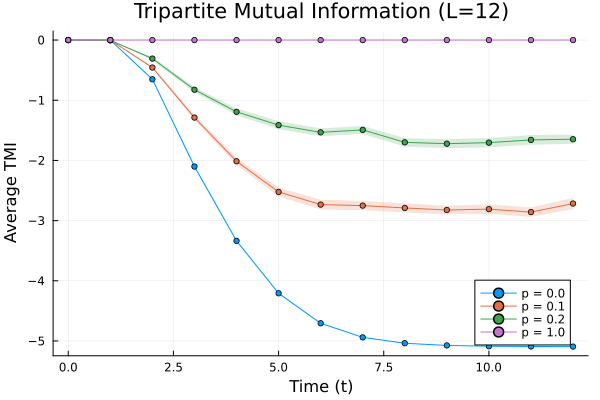

Plot saved as TMI_averaged_L12.svg


In [11]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
L = 12
T = 12.0
dt = 1.0  # Assuming dt=1.0 based on your previous code
num_shots = 500 # You mentioned 500 shots
p_values = [0.0, 0.1, 0.2, 1.0]

# Directory where files are saved (current dir by default)
data_dir = "." 

# ==========================================
# PROCESSING LOOP
# ==========================================

# Initialize Plot
plt = plot(
    title = "Tripartite Mutual Information (L=$L)",
    xlabel = "Time (t)",
    ylabel = "Average TMI",
    legend = :bottomright,
    lw = 2
)

results = Dict()

for p in p_values
    println("Processing p = $p ...")
    
    # Store all trajectories for this p
    # We don't know the exact length of the time series yet, so we'll push vectors
    trajectories = Vector{Vector{Float64}}()

    for s in 1:num_shots
        # Construct filename matching your generation script
        # Pattern: L12,T12.0,dt1.0,p0.1,dirQ,s1_tmi.npy
        filename = "L$(L),T$(T),p$(p),s$(s)_tmi.npy"
        filepath = joinpath(data_dir, filename)

        if isfile(filepath)
            # Load the data
            tmi_data = npzread(filepath)
            push!(trajectories, tmi_data)
        else
            # Optional: warn if a specific shot is missing
            # println("  Warning: Shot $s not found ($filename)")
        end
    end

    if isempty(trajectories)
        println("  No data found for p=$p. Skipping.")
        continue
    end

    # Convert vector of vectors to a Matrix for easy averaging
    # Matrix dimensions: (TimeSteps x NumRealizations)
    # hcat concatenates arrays horizontally, so we transpose to get (Realizations x Time)
    data_matrix = hcat(trajectories...) 
    
    # Calculate Mean and Standard Error (SEM)
    # dims=2 averages across the realizations (columns)
    avg_tmi = mean(data_matrix, dims=2)[:]
    std_tmi = std(data_matrix, dims=2)[:]
    sem_tmi = std_tmi ./ sqrt(length(trajectories)) # Standard Error

    # Save processed data for this p
    results[p] = avg_tmi

    # Add to Plot
    time_axis = 0:dt:T  # Assumes your data includes t=0
    
    # Check if time axis length matches data length
    # If standard logic applies, length should be T/dt + 1
    if length(time_axis) != length(avg_tmi)
        # Adjust time axis if necessary based on data shape
        time_axis = range(0, step=dt, length=length(avg_tmi))
    end

    plot!(plt, time_axis, avg_tmi, 
        ribbon = sem_tmi, # Adds a shaded error region
        label = "p = $p", 
        marker = :circle, 
        markersize = 3,
        fillalpha = 0.2
    )
end

# ==========================================
# OUTPUT
# ==========================================

display(plt)
savefig(plt, "TMI_averaged_L$(L).svg")
println("Plot saved as TMI_averaged_L$(L).svg")

# Optional: Save the averaged data to a new summary file
#npzwrite("TMI_averaged_summary_L$(L).npy", results)

In [ ]:
function main()
    s = ArgParseSettings()
    @add_arg_table! s begin
        "--L"
            arg_type = Int
            required = true
        "--p"
            arg_type = Float64
            required = true
        "--start_shot"
            arg_type = Int
            required = true
        "--end_shot"
            arg_type = Int
            required = true
    end

    parsed = parse_args(s)
    L = parsed["L"]
    p = parsed["p"]
    start_shot = parsed["start_shot"]
    end_shot = parsed["end_shot"]

    # enforce positive integers
    if start_shot < 1 || end_shot < 1
        error("Shot indices must be positive integers")
    end
    if end_shot < start_shot
        error("end_shot (end_shot) must be >= start_shot (start_shot)")
    end

    for T in [10.0*L]
        for shot in start_shot:end_shot
            Entropy_t(L, T, dt, p, shot)
        end
    end
end

main()

Running sweep...
Starting Simulation...
Threads available: 1
Simulating L = 6 ........... Done.
Simulating L = 8 ........... Done.
Simulating L = 10 ........... Done.
Generating plot...


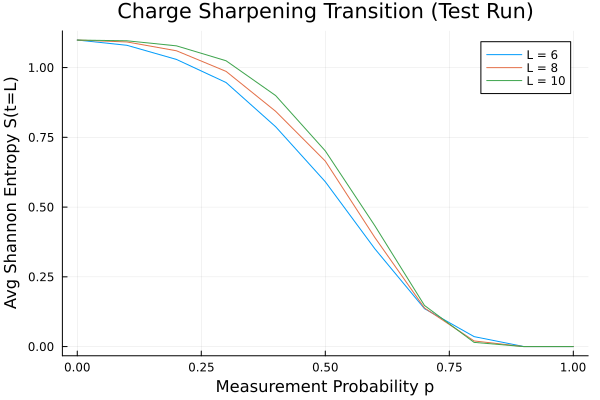

Done! Plot displayed.


In [2]:
using LinearAlgebra
using Random
using StatsBase
using Statistics
using Plots
using Printf

# ==========================================
# 1. PHYSICS HELPER FUNCTIONS
# ==========================================

function superposition_state(L::Int)
    psi = ones(ComplexF64, 3^L)
    return psi ./ norm(psi)
end

function construct_gate()
    # Haar random 3x3 block generator
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

function apply_gate!(psi, U, site, L)
    dL, dR = 3^(site-1), 3^(L-site-1)
    psi_t = permutedims(reshape(psi, dL, 3, 3, dR), (2, 3, 1, 4))
    psi_new = U * reshape(psi_t, 9, :)
    psi[:] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
end

function measure_site!(psi, site, L)
    dL, dR = 3^(site-1), 3^(L-site)
    psi_view = reshape(psi, dL, 3, dR)
    
    probs = [sum(abs2, psi_view[:, s, :]) for s in 1:3]
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        for s in 1:3
            if s != outcome
                psi_view[:, s, :] .= 0
            else
                psi_view[:, s, :] .*= norm_fac
            end
        end
    end
end

function shannon_entropy(psi, L)
    probs = zeros(3)
    for i in 0:(3^L - 1)
        amp = abs2(psi[i+1])
        if amp > 1e-15
            v, q = i, 0
            for _ in 1:L; q += v % 3; v ÷= 3; end
            probs[(q % 3) + 1] += amp
        end
    end
    return -sum(p -> p > 1e-15 ? p * log(p) : 0.0, probs)
end

# ==========================================
# 2. SIMULATION LOOP (Your Structure)
# ==========================================

function run_single_realization(L, p)
    # Initial State: Equal superposition normalized
    psi = superposition_state(L)
    
    # Evolve for t = 1 to L (or 2*L depending on your convention)
    # Using T = L here for quick testing
    for t in 1:L
        
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi, construct_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-1)
            apply_gate!(psi, construct_gate(), x, L)
        end
        
        # Measurements
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(psi, l, L)
                end
            end
        end
    end
    
    return shannon_entropy(psi, L)
end

function run_experiment_sweep()
    # --- PARAMETERS (Reduced for Testing) ---
    L_values = [6, 8, 10]              # Small system sizes
    p_values = 0.0:0.1:1.0         # 11 points
    n_realizations = 1000            # Few shots for speed
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        print("Simulating L = $L ")
        avg_entropies = Float64[]
        
        for p in p_values
            # Run realizations in parallel for speed
            # Pre-allocate array to avoid race conditions
            batch_entropies = zeros(Float64, n_realizations)
            
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            
            # Average the results for this p
            push!(avg_entropies, mean(batch_entropies))
            print(".") # Progress bar dot
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. PLOTTING
# ==========================================

println("Running sweep...")
p_vals, data = run_experiment_sweep()

println("Generating plot...")
# Create the plot
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Avg Shannon Entropy S(t=L)",
    title = "Charge Sharpening Transition (Test Run)",
    legend = :topright,
    lw = 2,
    marker = :circle
)

for L in sort(collect(keys(data)))
    entropies = data[L]
    plot!(plt, p_vals, entropies, label = "L = $L")
end

display(plt)
println("Done! Plot displayed.")
# savefig("test_sharpening.png")

Starting Simulation (PBC Enabled)...
Threads available: 1
Simulating L = 6 ........... Done.
Simulating L = 8 ........... Done.
Simulating L = 10 ........... Done.

Generating Plot...


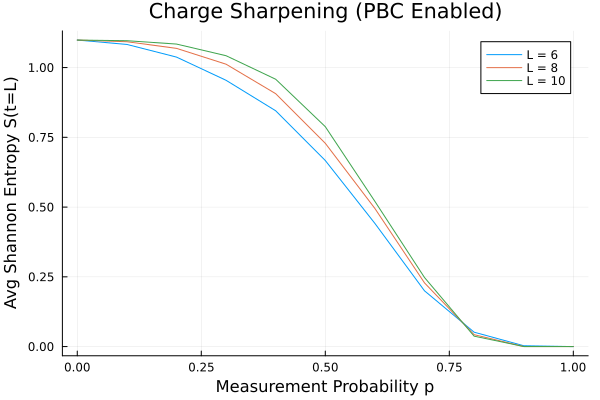

Plot displayed.


In [4]:
using LinearAlgebra
using Random
using StatsBase
using Statistics
using Plots
using Printf

# ==========================================
# 1. PHYSICS HELPER FUNCTIONS
# ==========================================

function superposition_state(L::Int)
    psi = ones(ComplexF64, 3^L)
    return psi ./ norm(psi)
end

function construct_gate()
    # Haar random 3x3 block generator
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

# Standard gate for sites i, i+1
function apply_gate!(psi, U, site, L)
    dL, dR = 3^(site-1), 3^(L-site-1)
    # Reshape -> Permute -> Multiply -> Permute -> Reshape
    psi_t = permutedims(reshape(psi, dL, 3, 3, dR), (2, 3, 1, 4))
    psi_new = U * reshape(psi_t, 9, :)
    psi[:] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
end

# NEW: Special gate for the boundary (Site L -> Site 1)
function apply_boundary_gate!(psi, U, L)
    # Reshape to isolate (Site 1, Middle, Site L)
    # Indices: 1, 2...L-1, L
    psi_reshaped = reshape(psi, 3, 3^(L-2), 3)
    
    # Permute to bring Site L and Site 1 together: (Site L, Site 1, Middle)
    psi_perm = permutedims(psi_reshaped, (3, 1, 2))
    
    # Flatten L and 1 into a size-9 vector dimension
    psi_mat = reshape(psi_perm, 9, :)
    
    # Apply Gate U (acts on L, 1)
    psi_new_mat = U * psi_mat
    
    # Reshape back to (L, 1, Middle)
    psi_new_tensor = reshape(psi_new_mat, 3, 3, :)
    
    # Permute back to original order: (Site 1, Middle, Site L)
    psi_final = permutedims(psi_new_tensor, (2, 3, 1))
    
    # Flatten back to state vector
    psi[:] = reshape(psi_final, :)
end

function measure_site!(psi, site, L)
    dL, dR = 3^(site-1), 3^(L-site)
    psi_view = reshape(psi, dL, 3, dR)
    
    probs = [sum(abs2, psi_view[:, s, :]) for s in 1:3]
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        for s in 1:3
            if s != outcome
                psi_view[:, s, :] .= 0
            else
                psi_view[:, s, :] .*= norm_fac
            end
        end
    end
end

function shannon_entropy(psi, L)
    probs = zeros(3)
    for i in 0:(3^L - 1)
        amp = abs2(psi[i+1])
        if amp > 1e-15
            v, q = i, 0
            for _ in 1:L; q += v % 3; v ÷= 3; end
            probs[(q % 3) + 1] += amp
        end
    end
    return -sum(p -> p > 1e-15 ? p * log(p) : 0.0, probs)
end

# ==========================================
# 2. SIMULATION LOGIC (With PBC)
# ==========================================

function run_single_realization(L, p)
    # Initial State: Equal superposition normalized
    psi = superposition_state(L)
    
    # Evolve for t = 1 to L
    for t in 1:L
        
        # --- Even Layer ---
        # Gates on (1,2), (3,4) ... (L-1, L)
        # Covers all sites if L is even
        for x in 1:2:(L-1)
            apply_gate!(psi, construct_gate(), x, L)
        end
        
        # --- Odd Layer ---
        # Gates on (2,3), (4,5) ... (L-2, L-1)
        for x in 2:2:(L-2)
            apply_gate!(psi, construct_gate(), x, L)
        end
        
        # *** PERIODIC BOUNDARY GATE ***
        # Connects Site L back to Site 1
        apply_boundary_gate!(psi, construct_gate(), L)

        # --- Measurements ---
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(psi, l, L)
                end
            end
        end
    end
    
    # Return entropy at final time t=L
    return shannon_entropy(psi, L)
end

function run_experiment_sweep()
    # --- PARAMETERS (Fast Test Mode) ---
    L_values = [6, 8, 10]              
    p_values = 0.0:0.1:1.0         
    n_realizations = 1000          # Small number for quick testing
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation (PBC Enabled)...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        print("Simulating L = $L ")
        
        # Arrays to store averaged results for each p
        avg_entropies = Float64[]
        
        for p in p_values
            
            # Run realizations in parallel
            batch_entropies = zeros(Float64, n_realizations)
            
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            
            push!(avg_entropies, mean(batch_entropies))
            print(".") 
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. EXECUTION & PLOTTING
# ==========================================

p_vals, data = run_experiment_sweep()

println("\nGenerating Plot...")
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Avg Shannon Entropy S(t=L)",
    title = "Charge Sharpening (PBC Enabled)",
    legend = :topright,
    lw = 2,
    marker = :circle
)

for L in sort(collect(keys(data)))
    entropies = data[L]
    plot!(plt, p_vals, entropies, label = "L = $L")
end

display(plt)
println("Plot displayed.")

Starting Simulation (Ancilla Protocol + PBC)...
Threads available: 1
Simulating L = 6 ........... Done.
Simulating L = 8 ........... Done.
Simulating L = 10 ........... Done.

Generating Plot...


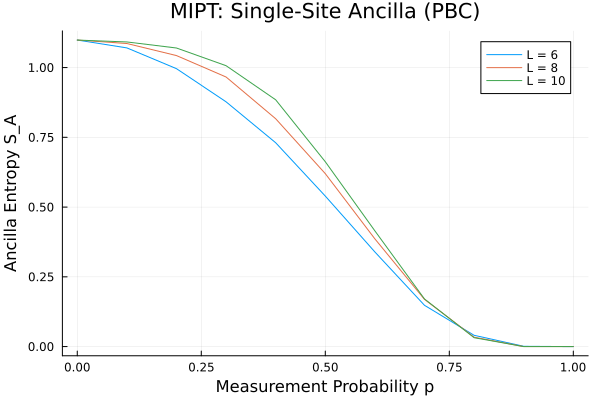

Plot displayed.


In [5]:
using LinearAlgebra
using Random
using StatsBase
using Statistics
using Plots
using Printf

# ==========================================
# 1. PHYSICS HELPER FUNCTIONS (Ancilla Compatible)
# ==========================================

# Initialize random Haar state (System only)
function random_haar_state(L::Int)
    psi = randn(ComplexF64, 3^L)
    return psi ./ norm(psi)
end

function construct_gate()
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    U = zeros(ComplexF64, 9, 9)
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

# Entangle System with Ancilla (Creates a Matrix: System x 3)
function entangle_ancilla(psi_sys::Vector{ComplexF64}, L::Int, site::Int)
    dL, dR = 3^(site-1), 3^(L-site)
    psi_tensor = reshape(psi_sys, dL, 3, dR)
    
    # State: (System_Dim, Ancilla_Dim=3)
    psi_total = zeros(ComplexF64, 3^L, 3)
    
    for state_idx in 1:3
        branch = copy(psi_tensor)
        # Project system site onto state_idx
        for s in 1:3
            if s != state_idx
                branch[:, s, :] .= 0
            end
        end
        # Normalize branch
        branch_vec = reshape(branch, :)
        if norm(branch_vec) > 1e-12
            branch_vec ./= norm(branch_vec)
        end
        psi_total[:, state_idx] = branch_vec
    end
    return psi_total ./ sqrt(3) # Global normalization
end

# Apply Gate (Handles Matrix State for Ancilla)
function apply_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site-1)
    # Apply gate to each ancilla branch independently
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_t = permutedims(reshape(psi_col, dL, 3, 3, dR), (2, 3, 1, 4))
        psi_new = U * reshape(psi_t, 9, :)
        psi[:, a] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
    end
end

# Apply PBC Boundary Gate (Handles Matrix State)
function apply_boundary_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, L::Int)
    # Gate connects Site L and Site 1
    for a in 1:3
        psi_col = @view psi[:, a]
        
        # Reshape to (Site 1, Middle, Site L)
        psi_reshaped = reshape(psi_col, 3, 3^(L-2), 3)
        
        # Permute to (Site L, Site 1, Middle)
        psi_perm = permutedims(psi_reshaped, (3, 1, 2))
        
        # Apply U
        psi_mat = reshape(psi_perm, 9, :)
        psi_new_mat = U * psi_mat
        
        # Reshape/Permute back to (Site 1, Middle, Site L)
        psi_new_tensor = reshape(psi_new_mat, 3, 3, :)
        psi_final = permutedims(psi_new_tensor, (2, 3, 1))
        
        psi[:, a] = reshape(psi_final, :)
    end
end

# Measurement (Sums probabilities across Ancilla branches)
function measure_site!(psi::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site)
    probs = zeros(Float64, 3)
    
    # 1. Sum probabilities from all 3 branches
    for a in 1:3
        psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
        for s in 1:3
            probs[s] += sum(abs2, psi_view[:, s, :])
        end
    end
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        # 2. Collapse all branches consistently
        for a in 1:3
            psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
            for s in 1:3
                if s != outcome
                    psi_view[:, s, :] .= 0
                else
                    psi_view[:, s, :] .*= norm_fac
                end
            end
        end
    end
end

# Ancilla Entropy (The Order Parameter)
function ancilla_entropy(psi::Matrix{ComplexF64})
    # Reduced density matrix of Ancilla (3x3)
    rho_A = psi' * psi 
    evals = eigen(Hermitian(rho_A)).values
    evals = max.(evals, 1e-20) # Avoid log(0)
    evals ./= sum(evals)
    return -sum(p -> p * log(p), evals)
end

# ==========================================
# 2. SIMULATION LOGIC (Ancilla + PBC)
# ==========================================

function run_single_realization(L, p)
    # 1. Initialize System in Random Haar State
    psi_sys = random_haar_state(L)
    
    # 2. Entangle with Ancilla at Middle Site
    target_site = div(L, 2) + 1
    psi_total = entangle_ancilla(psi_sys, L, target_site)
    
    # 3. Evolve (Time T = L)
    for t in 1:L
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary Gate
        apply_boundary_gate!(psi_total, construct_gate(), L)

        # Measurements
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(psi_total, l, L)
                end
            end
        end
    end
    
    # Return ANCILLA entropy
    return ancilla_entropy(psi_total)
end

function run_experiment_sweep()
    # --- PARAMETERS (Fast Test Mode) ---
    L_values = [6, 8, 10]              
    p_values = 0.0:0.1:1.0         
    n_realizations = 500  # Low count for quick testing
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation (Ancilla Protocol + PBC)...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        print("Simulating L = $L ")
        avg_entropies = Float64[]
        
        for p in p_values
            batch_entropies = zeros(Float64, n_realizations)
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            push!(avg_entropies, mean(batch_entropies))
            print(".") 
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. PLOTTING
# ==========================================

p_vals, data = run_experiment_sweep()

println("\nGenerating Plot...")
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Ancilla Entropy S_A",
    title = "MIPT: Single-Site Ancilla (PBC)",
    legend = :topright,
    lw = 2,
    marker = :circle
)

for L in sort(collect(keys(data)))
    entropies = data[L]
    plot!(plt, p_vals, entropies, label = "L = $L")
end

display(plt)
println("Plot displayed.")

In [1]:
function expectation_value_Q(psi::Vector{ComplexF64}, L::Int)
    expected_Q = 0.0
    
    for idx in 1:(3^L)
        prob = abs2(psi[idx]) # |ψ_i|^2
        
        # Optimization: Only calculate charge if the state has non-zero probability
        if prob > 1e-15
            state_int = idx - 1
            q_tot = 0
            
            # Decode the integer into base-3 digits to find local charges
            for _ in 1:L
                q_tot += state_int % 3
                state_int ÷= 3
            end
            
            # Calculate total charge modulo 3 for this basis state
            Q_i = q_tot % 3
            
            # Add to the expectation value
            expected_Q += Q_i * prob
        end
    end
    
    return expected_Q
end

expectation_value_Q (generic function with 1 method)

In [2]:
function all_zero_state(L::Int)
    # Total dimension of the Hilbert space
    dim = 3^L
    
    # Initialize a state vector of all zeroes
    psi = zeros(ComplexF64, dim)
    
    # Set the amplitude of the |00...0> state to 1
    psi[1] = 1.0 + 0.0im
    
    return psi
end

all_zero_state (generic function with 1 method)

In [3]:
psi = all_zero_state(8)

6561-element Vector{ComplexF64}:
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
     ⋮
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im

In [4]:
expectation_value_Q(psi, 8)

0.0

In [6]:
function uniform_basis_state(L::Int, q_val::Int)
    @assert q_val in [0, 1, 2] "qutrit state must be 0, 1, or 2"
    
    dim = 3^L
    psi = zeros(ComplexF64, dim)
    
    # Calculate the 0-based index for the uniform state
    # For q_val=0: index is 0
    # For q_val=1: index is (3^L - 1) / 2
    # For q_val=2: index is 3^L - 1
    idx_0_based = q_val * div(3^L - 1, 2)
    
    # Julia uses 1-based array indexing, so we add 1
    psi[idx_0_based + 1] = 1.0 + 0.0im
    
    return psi
end

uniform_basis_state (generic function with 2 methods)

In [9]:
psi = uniform_basis_state(8, 1) # Uniform superposition of all states with total charge 1 mod 3

6561-element Vector{ComplexF64}:
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
     ⋮
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im

In [11]:
expectation_value_Q(psi, 8)

2.0

Starting Simulation (Direct Initialization + PBC)...
Threads available: 1
Simulating L = 6 ........... Done.
Simulating L = 8 ........... Done.
Simulating L = 10 ........... Done.

Generating Plot...


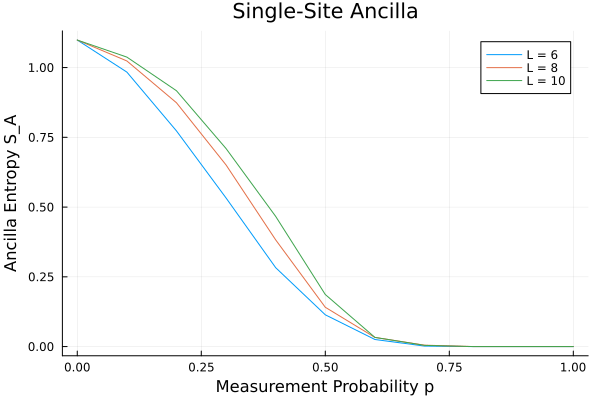

Plot displayed.


In [12]:
using LinearAlgebra
using Random
using StatsBase
using Statistics
using Plots
using Printf

# ==========================================
# 1. PHYSICS HELPER FUNCTIONS
# ==========================================

# Instantly construct the specific superposition directly in the matrix
function initial_entangled_state_direct(L::Int)
    @assert L >= 2 "System size must be at least 2"
    
    # State matrix: (System_Dim, Ancilla_Dim=3)
    psi_total = zeros(ComplexF64, 3^L, 3)
    
    # Branch 1: |00...00>_S ⊗ |0>_A  (Column 1)
    # All sites are 0, base-3 integer is 0.
    idx_1 = 0
    psi_total[idx_1 + 1, 1] = 1.0 / sqrt(3)
    
    # Branch 2: |00...↑↓>_S ⊗ |↑>_A  (Column 2)
    # ↑ (1) at L-1, ↓ (2) at L
    idx_2 = 1 * 3^(L-2) + 2 * 3^(L-1)
    psi_total[idx_2 + 1, 2] = 1.0 / sqrt(3)
    
    # Branch 3: |00...↓↑>_S ⊗ |↓>_A  (Column 3)
    # ↓ (2) at L-1, ↑ (1) at L
    idx_3 = 2 * 3^(L-2) + 1 * 3^(L-1)
    psi_total[idx_3 + 1, 3] = 1.0 / sqrt(3)
    
    return psi_total
end

function construct_gate()
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    # Block diagonal structure ensures Charge Conservation (mod 3)
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

# Apply Gate (Handles Matrix State)
function apply_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site-1)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_t = permutedims(reshape(psi_col, dL, 3, 3, dR), (2, 3, 1, 4))
        psi_new = U * reshape(psi_t, 9, :)
        psi[:, a] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
    end
end

# Apply PBC Boundary Gate
function apply_boundary_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, L::Int)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_reshaped = reshape(psi_col, 3, 3^(L-2), 3)
        psi_perm = permutedims(psi_reshaped, (3, 1, 2)) # (L, 1, Middle)
        psi_mat = reshape(psi_perm, 9, :)
        psi_new_mat = U * psi_mat
        psi_new_tensor = reshape(psi_new_mat, 3, 3, :)
        psi_final = permutedims(psi_new_tensor, (2, 3, 1)) # (1, Middle, L)
        psi[:, a] = reshape(psi_final, :)
    end
end

# Measurement (Sums probabilities across Ancilla branches)
function measure_site!(psi::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site)
    probs = zeros(Float64, 3)
    
    # 1. Sum probabilities from all 3 branches
    for a in 1:3
        psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
        for s in 1:3
            probs[s] += sum(abs2, psi_view[:, s, :])
        end
    end
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        # 2. Collapse all branches consistently
        for a in 1:3
            psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
            for s in 1:3
                if s != outcome
                    psi_view[:, s, :] .= 0
                else
                    psi_view[:, s, :] .*= norm_fac
                end
            end
        end
    end
end

# Ancilla Entropy
function ancilla_entropy(psi::Matrix{ComplexF64})
    rho_A = psi' * psi 
    evals = eigen(Hermitian(rho_A)).values
    evals = max.(evals, 1e-20)
    evals ./= sum(evals)
    return -sum(p -> p * log(p), evals)
end

# ==========================================
# 2. SIMULATION LOGIC
# ==========================================

function run_single_realization(L, p)
    # 1. Initialize Direct Edge-Entangled State
    # Already normalized and in the Q=0 sector
    psi_total = initial_entangled_state_direct(L)
    
    # 2. Evolve (T = L)
    for t in 1:L
        # Even Layer (1,2), (3,4), ...
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer (2,3), (4,5), ...
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary (L, 1)
        apply_boundary_gate!(psi_total, construct_gate(), L)

        # Measurements
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(psi_total, l, L)
                end
            end
        end
    end
    
    return ancilla_entropy(psi_total)
end

function run_experiment_sweep()
    # --- PARAMETERS ---
    L_values = [6, 8, 10]              
    p_values = 0.0:0.1:1.0         
    n_realizations = 500
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation (Direct Initialization + PBC)...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        print("Simulating L = $L ")
        avg_entropies = Float64[]
        
        for p in p_values
            batch_entropies = zeros(Float64, n_realizations)
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            push!(avg_entropies, mean(batch_entropies))
            print(".") 
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. EXECUTION
# ==========================================

p_vals, data = run_experiment_sweep()

println("\nGenerating Plot...")
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Ancilla Entropy S_A",
    title = "Single-Site Ancilla",
    legend = :topright,
    lw = 2,
    markersize = 3,
    marker = :circle
)

for L in sort(collect(keys(data)))
    entropies = data[L]
    plot!(plt, p_vals, entropies, label = "L = $L")
end

display(plt)
println("Plot displayed.")

Starting Simulation (Two-Phase Evolution)...
Threads available: 1
Simulating L = 6 ........... Done.
Simulating L = 8 ........... Done.
Simulating L = 10 ........... Done.

Generating Plot...


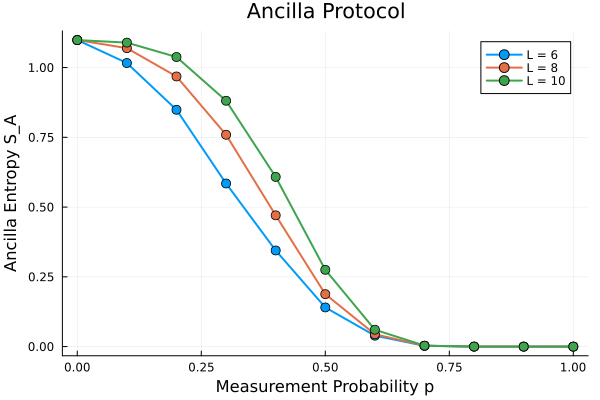

Plot displayed.


In [1]:
using LinearAlgebra
using Random
using StatsBase
using Statistics
using Plots
using Printf

# ==========================================
# 1. PHYSICS HELPER FUNCTIONS
# ==========================================

# Instantly construct the specific superposition directly in the matrix
function initial_entangled_state_direct(L::Int)
    @assert L >= 2 "System size must be at least 2"
    
    # State matrix: (System_Dim, Ancilla_Dim=3)
    psi_total = zeros(ComplexF64, 3^L, 3)
    
    # Branch 1: |00...00>_S ⊗ |0>_A  (Column 1)
    # All sites are 0, base-3 integer is 0.
    idx_1 = 0
    psi_total[idx_1 + 1, 1] = 1.0 / sqrt(3)
    
    # Branch 2: |00...↑↓>_S ⊗ |↑>_A  (Column 2)
    # ↑ (1) at L-1, ↓ (2) at L
    idx_2 = 1 * 3^(L-2) + 2 * 3^(L-1)
    psi_total[idx_2 + 1, 2] = 1.0 / sqrt(3)
    
    # Branch 3: |00...↓↑>_S ⊗ |↓>_A  (Column 3)
    # ↓ (2) at L-1, ↑ (1) at L
    idx_3 = 2 * 3^(L-2) + 1 * 3^(L-1)
    psi_total[idx_3 + 1, 3] = 1.0 / sqrt(3)
    
    return psi_total
end

function construct_gate()
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    # Block diagonal structure ensures Charge Conservation (mod 3)
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

# Apply Gate (Handles Matrix State)
function apply_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site-1)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_t = permutedims(reshape(psi_col, dL, 3, 3, dR), (2, 3, 1, 4))
        psi_new = U * reshape(psi_t, 9, :)
        psi[:, a] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
    end
end

# Apply PBC Boundary Gate
function apply_boundary_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, L::Int)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_reshaped = reshape(psi_col, 3, 3^(L-2), 3)
        psi_perm = permutedims(psi_reshaped, (3, 1, 2)) # (L, 1, Middle)
        psi_mat = reshape(psi_perm, 9, :)
        psi_new_mat = U * psi_mat
        psi_new_tensor = reshape(psi_new_mat, 3, 3, :)
        psi_final = permutedims(psi_new_tensor, (2, 3, 1)) # (1, Middle, L)
        psi[:, a] = reshape(psi_final, :)
    end
end

# Measurement (Sums probabilities across Ancilla branches)
function measure_site!(psi::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site)
    probs = zeros(Float64, 3)
    
    # 1. Sum probabilities from all 3 branches
    for a in 1:3
        psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
        for s in 1:3
            probs[s] += sum(abs2, psi_view[:, s, :])
        end
    end
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        # 2. Collapse all branches consistently
        for a in 1:3
            psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
            for s in 1:3
                if s != outcome
                    psi_view[:, s, :] .= 0
                else
                    psi_view[:, s, :] .*= norm_fac
                end
            end
        end
    end
end

# Ancilla Entropy
function ancilla_entropy(psi::Matrix{ComplexF64})
    rho_A = psi' * psi 
    evals = eigen(Hermitian(rho_A)).values
    evals = max.(evals, 1e-20)
    evals ./= sum(evals)
    return -sum(p -> p * log(p), evals)
end

# ==========================================
# 2. SIMULATION LOGIC
# ==========================================

function run_single_realization(L, p)
    # 1. Initialize Direct Edge-Entangled State
    psi_total = initial_entangled_state_direct(L)
    
    # ==========================================
    # PHASE 1: Scrambling (No Measurements)
    # Evolve for t = L to deeply entangle the state
    # ==========================================
    for t in 1:L
        # Even Layer (1,2), (3,4), ...
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer (2,3), (4,5), ...
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary (L, 1)
        apply_boundary_gate!(psi_total, construct_gate(), L)
    end
    
    # ==========================================
    # PHASE 2: Dynamics (With Measurements)
    # Evolve for another t = L with measurement probability p
    # ==========================================
    for t in 1:L
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary
        apply_boundary_gate!(psi_total, construct_gate(), L)

        # Measurements
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(psi_total, l, L)
                end
            end
        end
    end
    
    return ancilla_entropy(psi_total)
end

function run_experiment_sweep()
    # --- PARAMETERS ---
    L_values = [6, 8, 10]              
    p_values = 0.0:0.1:1.0         
    n_realizations = 500
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation (Two-Phase Evolution)...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        print("Simulating L = $L ")
        avg_entropies = Float64[]
        
        for p in p_values
            batch_entropies = zeros(Float64, n_realizations)
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            push!(avg_entropies, mean(batch_entropies))
            print(".") 
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. EXECUTION & PLOTTING
# ==========================================

p_vals, data = run_experiment_sweep()

println("\nGenerating Plot...")

# Set up the base plot
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Ancilla Entropy S_A",
    title = "Ancilla Protocol",
    legend = :topright,
    grid = true
)

# Plot each system size with explicit circle markers
for L in sort(collect(keys(data)))
    entropies = data[L]
    plot!(plt, p_vals, entropies, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5, 
        lw = 2
    )
end

display(plt)
println("Plot displayed.")

Starting Simulation (Two-Phase Evolution)...
Threads available: 1
Simulating L = 6 ......... Done.
Simulating L = 8 ......... Done.
Simulating L = 10 ......... Done.

Generating Plot...


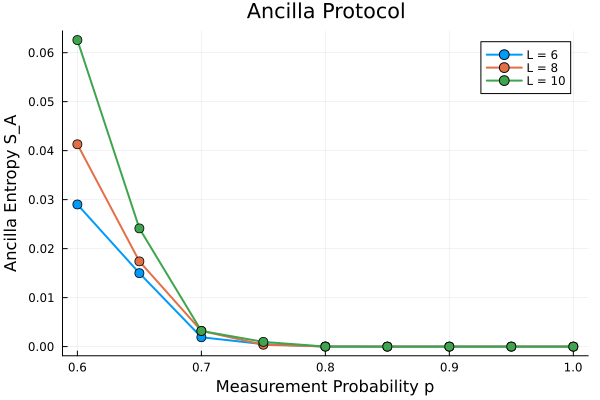

Plot displayed.


In [2]:
using LinearAlgebra
using Random
using StatsBase
using Statistics
using Plots
using Printf

# ==========================================
# 1. PHYSICS HELPER FUNCTIONS
# ==========================================

# Instantly construct the specific superposition directly in the matrix
function initial_entangled_state_direct(L::Int)
    @assert L >= 2 "System size must be at least 2"
    
    # State matrix: (System_Dim, Ancilla_Dim=3)
    psi_total = zeros(ComplexF64, 3^L, 3)
    
    # Branch 1: |00...00>_S ⊗ |0>_A  (Column 1)
    # All sites are 0, base-3 integer is 0.
    idx_1 = 0
    psi_total[idx_1 + 1, 1] = 1.0 / sqrt(3)
    
    # Branch 2: |00...↑↓>_S ⊗ |↑>_A  (Column 2)
    # ↑ (1) at L-1, ↓ (2) at L
    idx_2 = 1 * 3^(L-2) + 2 * 3^(L-1)
    psi_total[idx_2 + 1, 2] = 1.0 / sqrt(3)
    
    # Branch 3: |00...↓↑>_S ⊗ |↓>_A  (Column 3)
    # ↓ (2) at L-1, ↑ (1) at L
    idx_3 = 2 * 3^(L-2) + 1 * 3^(L-1)
    psi_total[idx_3 + 1, 3] = 1.0 / sqrt(3)
    
    return psi_total
end

function construct_gate()
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    # Block diagonal structure ensures Charge Conservation (mod 3)
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

# Apply Gate (Handles Matrix State)
function apply_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site-1)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_t = permutedims(reshape(psi_col, dL, 3, 3, dR), (2, 3, 1, 4))
        psi_new = U * reshape(psi_t, 9, :)
        psi[:, a] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
    end
end

# Apply PBC Boundary Gate
function apply_boundary_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, L::Int)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_reshaped = reshape(psi_col, 3, 3^(L-2), 3)
        psi_perm = permutedims(psi_reshaped, (3, 1, 2)) # (L, 1, Middle)
        psi_mat = reshape(psi_perm, 9, :)
        psi_new_mat = U * psi_mat
        psi_new_tensor = reshape(psi_new_mat, 3, 3, :)
        psi_final = permutedims(psi_new_tensor, (2, 3, 1)) # (1, Middle, L)
        psi[:, a] = reshape(psi_final, :)
    end
end

# Measurement (Sums probabilities across Ancilla branches)
function measure_site!(psi::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site)
    probs = zeros(Float64, 3)
    
    # 1. Sum probabilities from all 3 branches
    for a in 1:3
        psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
        for s in 1:3
            probs[s] += sum(abs2, psi_view[:, s, :])
        end
    end
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        # 2. Collapse all branches consistently
        for a in 1:3
            psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
            for s in 1:3
                if s != outcome
                    psi_view[:, s, :] .= 0
                else
                    psi_view[:, s, :] .*= norm_fac
                end
            end
        end
    end
end

# Ancilla Entropy
function ancilla_entropy(psi::Matrix{ComplexF64})
    rho_A = psi' * psi 
    evals = eigen(Hermitian(rho_A)).values
    evals = max.(evals, 1e-20)
    evals ./= sum(evals)
    return -sum(p -> p * log(p), evals)
end

# ==========================================
# 2. SIMULATION LOGIC
# ==========================================

function run_single_realization(L, p)
    # 1. Initialize Direct Edge-Entangled State
    psi_total = initial_entangled_state_direct(L)
    
    # ==========================================
    # PHASE 1: Scrambling (No Measurements)
    # Evolve for t = L to deeply entangle the state
    # ==========================================
    for t in 1:L
        # Even Layer (1,2), (3,4), ...
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer (2,3), (4,5), ...
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary (L, 1)
        apply_boundary_gate!(psi_total, construct_gate(), L)
    end
    
    # ==========================================
    # PHASE 2: Dynamics (With Measurements)
    # Evolve for another t = L with measurement probability p
    # ==========================================
    for t in 1:L
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary
        apply_boundary_gate!(psi_total, construct_gate(), L)

        # Measurements
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(psi_total, l, L)
                end
            end
        end
    end
    
    return ancilla_entropy(psi_total)
end

function run_experiment_sweep()
    # --- PARAMETERS ---
    L_values = [6, 8, 10]              
    p_values = 0.6:0.05:1.0         
    n_realizations = 500
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation (Two-Phase Evolution)...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        print("Simulating L = $L ")
        avg_entropies = Float64[]
        
        for p in p_values
            batch_entropies = zeros(Float64, n_realizations)
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            push!(avg_entropies, mean(batch_entropies))
            print(".") 
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. EXECUTION & PLOTTING
# ==========================================

p_vals, data = run_experiment_sweep()

println("\nGenerating Plot...")

# Set up the base plot
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Ancilla Entropy S_A",
    title = "Ancilla Protocol",
    legend = :topright,
    grid = true
)

# Plot each system size with explicit circle markers
for L in sort(collect(keys(data)))
    entropies = data[L]
    plot!(plt, p_vals, entropies, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5, 
        lw = 2
    )
end

display(plt)
println("Plot displayed.")

Starting Simulation (Two-Phase Evolution)...
Threads available: 1
Simulating L = 6 ......... Done.
Simulating L = 8 ......... Done.
Simulating L = 10 ......... Done.

Generating Plot...


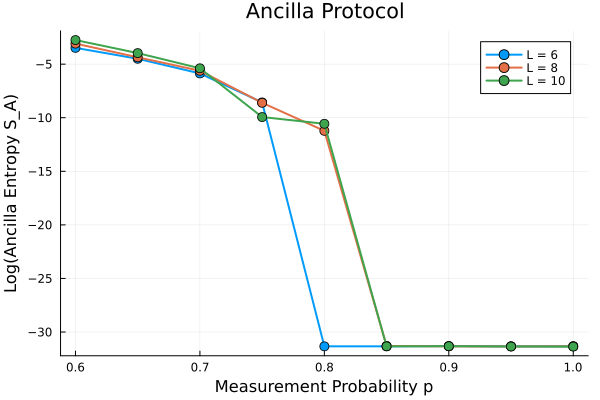

Plot displayed.


In [3]:
using LinearAlgebra
using Random
using StatsBase
using Statistics
using Plots
using Printf

# ==========================================
# 1. PHYSICS HELPER FUNCTIONS
# ==========================================

# Instantly construct the specific superposition directly in the matrix
function initial_entangled_state_direct(L::Int)
    @assert L >= 2 "System size must be at least 2"
    
    # State matrix: (System_Dim, Ancilla_Dim=3)
    psi_total = zeros(ComplexF64, 3^L, 3)
    
    # Branch 1: |00...00>_S ⊗ |0>_A  (Column 1)
    # All sites are 0, base-3 integer is 0.
    idx_1 = 0
    psi_total[idx_1 + 1, 1] = 1.0 / sqrt(3)
    
    # Branch 2: |00...↑↓>_S ⊗ |↑>_A  (Column 2)
    # ↑ (1) at L-1, ↓ (2) at L
    idx_2 = 1 * 3^(L-2) + 2 * 3^(L-1)
    psi_total[idx_2 + 1, 2] = 1.0 / sqrt(3)
    
    # Branch 3: |00...↓↑>_S ⊗ |↓>_A  (Column 3)
    # ↓ (2) at L-1, ↑ (1) at L
    idx_3 = 2 * 3^(L-2) + 1 * 3^(L-1)
    psi_total[idx_3 + 1, 3] = 1.0 / sqrt(3)
    
    return psi_total
end

function construct_gate()
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    # Block diagonal structure ensures Charge Conservation (mod 3)
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

# Apply Gate (Handles Matrix State)
function apply_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site-1)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_t = permutedims(reshape(psi_col, dL, 3, 3, dR), (2, 3, 1, 4))
        psi_new = U * reshape(psi_t, 9, :)
        psi[:, a] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
    end
end

# Apply PBC Boundary Gate
function apply_boundary_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, L::Int)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_reshaped = reshape(psi_col, 3, 3^(L-2), 3)
        psi_perm = permutedims(psi_reshaped, (3, 1, 2)) # (L, 1, Middle)
        psi_mat = reshape(psi_perm, 9, :)
        psi_new_mat = U * psi_mat
        psi_new_tensor = reshape(psi_new_mat, 3, 3, :)
        psi_final = permutedims(psi_new_tensor, (2, 3, 1)) # (1, Middle, L)
        psi[:, a] = reshape(psi_final, :)
    end
end

# Measurement (Sums probabilities across Ancilla branches)
function measure_site!(psi::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site)
    probs = zeros(Float64, 3)
    
    # 1. Sum probabilities from all 3 branches
    for a in 1:3
        psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
        for s in 1:3
            probs[s] += sum(abs2, psi_view[:, s, :])
        end
    end
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        # 2. Collapse all branches consistently
        for a in 1:3
            psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
            for s in 1:3
                if s != outcome
                    psi_view[:, s, :] .= 0
                else
                    psi_view[:, s, :] .*= norm_fac
                end
            end
        end
    end
end

# Ancilla Entropy
function ancilla_entropy(psi::Matrix{ComplexF64})
    rho_A = psi' * psi 
    evals = eigen(Hermitian(rho_A)).values
    evals = max.(evals, 1e-20)
    evals ./= sum(evals)
    return -sum(p -> p * log(p), evals)
end

# ==========================================
# 2. SIMULATION LOGIC
# ==========================================

function run_single_realization(L, p)
    # 1. Initialize Direct Edge-Entangled State
    psi_total = initial_entangled_state_direct(L)
    
    # ==========================================
    # PHASE 1: Scrambling (No Measurements)
    # Evolve for t = L to deeply entangle the state
    # ==========================================
    for t in 1:L
        # Even Layer (1,2), (3,4), ...
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer (2,3), (4,5), ...
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary (L, 1)
        apply_boundary_gate!(psi_total, construct_gate(), L)
    end
    
    # ==========================================
    # PHASE 2: Dynamics (With Measurements)
    # Evolve for another t = L with measurement probability p
    # ==========================================
    for t in 1:L
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary
        apply_boundary_gate!(psi_total, construct_gate(), L)

        # Measurements
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(psi_total, l, L)
                end
            end
        end
    end
    
    return ancilla_entropy(psi_total)
end

function run_experiment_sweep()
    # --- PARAMETERS ---
    L_values = [6, 8, 10]              
    p_values = 0.6:0.05:1.0         
    n_realizations = 500
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation (Two-Phase Evolution)...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        print("Simulating L = $L ")
        avg_entropies = Float64[]
        
        for p in p_values
            batch_entropies = zeros(Float64, n_realizations)
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            push!(avg_entropies, mean(batch_entropies))
            print(".") 
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. EXECUTION & PLOTTING
# ==========================================

p_vals, data = run_experiment_sweep()

println("\nGenerating Plot...")

# Set up the base plot
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Log(Ancilla Entropy S_A)",
    title = "Ancilla Protocol",
    legend = :topright,
    grid = true
)

# Plot each system size with explicit circle markers
for L in sort(collect(keys(data)))
    entropies = data[L]
    logentropies = log.(entropies .+ 1e-20)  # Add small value to avoid log(0)
    plot!(plt, p_vals, logentropies, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5, 
        lw = 2
    )
end

display(plt)
println("Plot displayed.")

Starting Simulation (GHZ Initialization + Two-Phase Evolution)...
Threads available: 1
Simulating L = 6 ........... Done.
Simulating L = 8 ........... Done.

Generating Plot...


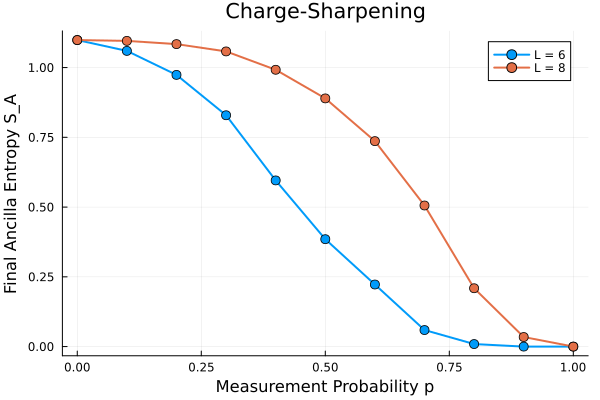

Plot displayed.


In [5]:
using LinearAlgebra
using Random
using StatsBase
using Statistics
using Plots
using Printf

# ==========================================
# 1. PHYSICS HELPER FUNCTIONS
# ==========================================

function initial_entangled_state_ghz(L::Int)
    @assert L >= 2 "System size must be at least 2"
    
    # State matrix: (System_Dim, Ancilla_Dim=3)
    psi_total = zeros(ComplexF64, 3^L, 3)
    
    # Branch 1: |00...00>_S ⊗ |0>_A  (Column 1)
    # Integer value of 000...0 in base 3 is 0
    idx_1 = 0
    psi_total[idx_1 + 1, 1] = 1.0 / sqrt(3)
    
    # Branch 2: |↑↑...↑↑>_S ⊗ |↑>_A  (Column 2)
    # Integer value of 111...1 in base 3 is (3^L - 1) / 2
    idx_2 = div(3^L - 1, 2)
    psi_total[idx_2 + 1, 2] = 1.0 / sqrt(3)
    
    # Branch 3: |↓↓...↓↓>_S ⊗ |↓>_A  (Column 3)
    # Integer value of 222...2 in base 3 is 3^L - 1
    idx_3 = 3^L - 1
    psi_total[idx_3 + 1, 3] = 1.0 / sqrt(3)
    
    return psi_total
end

function construct_gate()
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    # Block diagonal structure
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

# Apply Gate (Handles Matrix State)
function apply_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site-1)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_t = permutedims(reshape(psi_col, dL, 3, 3, dR), (2, 3, 1, 4))
        psi_new = U * reshape(psi_t, 9, :)
        psi[:, a] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
    end
end

# Apply PBC Boundary Gate
function apply_boundary_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, L::Int)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_reshaped = reshape(psi_col, 3, 3^(L-2), 3)
        psi_perm = permutedims(psi_reshaped, (3, 1, 2)) # (L, 1, Middle)
        psi_mat = reshape(psi_perm, 9, :)
        psi_new_mat = U * psi_mat
        psi_new_tensor = reshape(psi_new_mat, 3, 3, :)
        psi_final = permutedims(psi_new_tensor, (2, 3, 1)) # (1, Middle, L)
        psi[:, a] = reshape(psi_final, :)
    end
end

# Measurement (Sums probabilities across Ancilla branches)
function measure_site!(psi::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site)
    probs = zeros(Float64, 3)
    
    # 1. Sum probabilities from all 3 branches
    for a in 1:3
        psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
        for s in 1:3
            probs[s] += sum(abs2, psi_view[:, s, :])
        end
    end
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        # 2. Collapse all branches consistently
        for a in 1:3
            psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
            for s in 1:3
                if s != outcome
                    psi_view[:, s, :] .= 0
                else
                    psi_view[:, s, :] .*= norm_fac
                end
            end
        end
    end
end

# Ancilla Entropy
function ancilla_entropy(psi::Matrix{ComplexF64})
    rho_A = psi' * psi 
    evals = eigen(Hermitian(rho_A)).values
    evals = max.(evals, 1e-20)
    evals ./= sum(evals)
    return -sum(p -> p * log(p), evals)
end

# ==========================================
# 2. SIMULATION LOGIC
# ==========================================

function run_single_realization(L, p)
    # 1. Initialize GHZ-like Entangled State
    psi_total = initial_entangled_state_ghz(L)
    
    # ==========================================
    # PHASE 1: Scrambling (No Measurements)
    # ==========================================
    for t in 1:L/2
        # Even Layer (1,2), (3,4), ...
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer (2,3), (4,5), ...
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary (L, 1)
        apply_boundary_gate!(psi_total, construct_gate(), L)
    end
    
    # ==========================================
    # PHASE 2: Dynamics (With Measurements)
    # ==========================================
    for t in 1:L/2
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary
        apply_boundary_gate!(psi_total, construct_gate(), L)

        # Measurements
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(psi_total, l, L)
                end
            end
        end
    end
    
    return ancilla_entropy(psi_total)
end

function run_experiment_sweep()
    # --- PARAMETERS ---
    L_values = [6, 8]              
    p_values = 0.0:0.1:1.0         
    n_realizations = 500 
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation (GHZ Initialization + Two-Phase Evolution)...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        print("Simulating L = $L ")
        avg_entropies = Float64[]
        
        for p in p_values
            batch_entropies = zeros(Float64, n_realizations)
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            push!(avg_entropies, mean(batch_entropies))
            print(".") 
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. EXECUTION & PLOTTING
# ==========================================

p_vals, data = run_experiment_sweep()

println("\nGenerating Plot...")

# Set up the base plot
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Final Ancilla Entropy S_A",
    title = "Charge-Sharpening",
    legend = :topright,
    grid = true
)

# Plot each system size with explicit circle markers
for L in sort(collect(keys(data)))
    entropies = data[L]
    plot!(plt, p_vals, entropies, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5, 
        lw = 2
    )
end

display(plt)
println("Plot displayed.")

Starting Simulation (GHZ Initialization + Two-Phase Evolution)...
Threads available: 1
Simulating L = 6 ........... Done.
Simulating L = 8 ........... Done.

Generating Plot...


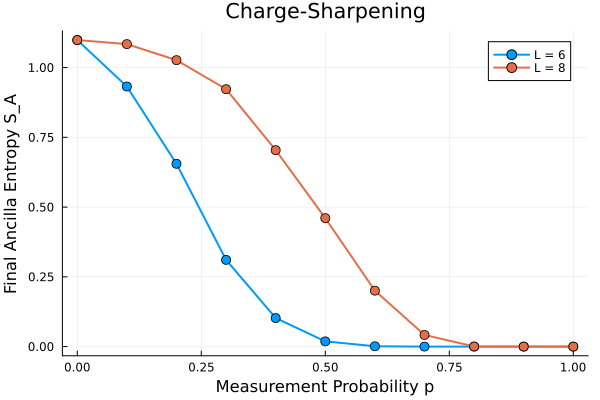

Plot displayed.


In [6]:
using LinearAlgebra
using Random
using StatsBase
using Statistics
using Plots
using Printf

# ==========================================
# 1. PHYSICS HELPER FUNCTIONS
# ==========================================

function initial_entangled_state_ghz(L::Int)
    @assert L >= 2 "System size must be at least 2"
    
    # State matrix: (System_Dim, Ancilla_Dim=3)
    psi_total = zeros(ComplexF64, 3^L, 3)
    
    # Branch 1: |00...00>_S ⊗ |0>_A  (Column 1)
    # Integer value of 000...0 in base 3 is 0
    idx_1 = 0
    psi_total[idx_1 + 1, 1] = 1.0 / sqrt(3)
    
    # Branch 2: |↑↑...↑↑>_S ⊗ |↑>_A  (Column 2)
    # Integer value of 111...1 in base 3 is (3^L - 1) / 2
    idx_2 = div(3^L - 1, 2)
    psi_total[idx_2 + 1, 2] = 1.0 / sqrt(3)
    
    # Branch 3: |↓↓...↓↓>_S ⊗ |↓>_A  (Column 3)
    # Integer value of 222...2 in base 3 is 3^L - 1
    idx_3 = 3^L - 1
    psi_total[idx_3 + 1, 3] = 1.0 / sqrt(3)
    
    return psi_total
end

function construct_gate()
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    # Block diagonal structure
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

# Apply Gate (Handles Matrix State)
function apply_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site-1)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_t = permutedims(reshape(psi_col, dL, 3, 3, dR), (2, 3, 1, 4))
        psi_new = U * reshape(psi_t, 9, :)
        psi[:, a] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
    end
end

# Apply PBC Boundary Gate
function apply_boundary_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, L::Int)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_reshaped = reshape(psi_col, 3, 3^(L-2), 3)
        psi_perm = permutedims(psi_reshaped, (3, 1, 2)) # (L, 1, Middle)
        psi_mat = reshape(psi_perm, 9, :)
        psi_new_mat = U * psi_mat
        psi_new_tensor = reshape(psi_new_mat, 3, 3, :)
        psi_final = permutedims(psi_new_tensor, (2, 3, 1)) # (1, Middle, L)
        psi[:, a] = reshape(psi_final, :)
    end
end

# Measurement (Sums probabilities across Ancilla branches)
function measure_site!(psi::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site)
    probs = zeros(Float64, 3)
    
    # 1. Sum probabilities from all 3 branches
    for a in 1:3
        psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
        for s in 1:3
            probs[s] += sum(abs2, psi_view[:, s, :])
        end
    end
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        # 2. Collapse all branches consistently
        for a in 1:3
            psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
            for s in 1:3
                if s != outcome
                    psi_view[:, s, :] .= 0
                else
                    psi_view[:, s, :] .*= norm_fac
                end
            end
        end
    end
end

# Ancilla Entropy
function ancilla_entropy(psi::Matrix{ComplexF64})
    rho_A = psi' * psi 
    evals = eigen(Hermitian(rho_A)).values
    evals = max.(evals, 1e-20)
    evals ./= sum(evals)
    return -sum(p -> p * log(p), evals)
end

# ==========================================
# 2. SIMULATION LOGIC
# ==========================================

function run_single_realization(L, p)
    # 1. Initialize GHZ-like Entangled State
    psi_total = initial_entangled_state_ghz(L)
    
    # ==========================================
    # PHASE 1: Scrambling (No Measurements)
    # ==========================================
    for t in 1:2*L
        # Even Layer (1,2), (3,4), ...
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer (2,3), (4,5), ...
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary (L, 1)
        apply_boundary_gate!(psi_total, construct_gate(), L)
    end
    
    # ==========================================
    # PHASE 2: Dynamics (With Measurements)
    # ==========================================
    for t in 1:2*L
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary
        apply_boundary_gate!(psi_total, construct_gate(), L)

        # Measurements
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(psi_total, l, L)
                end
            end
        end
    end
    
    return ancilla_entropy(psi_total)
end

function run_experiment_sweep()
    # --- PARAMETERS ---
    L_values = [6, 8]              
    p_values = 0.0:0.1:1.0         
    n_realizations = 500 
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation (GHZ Initialization + Two-Phase Evolution)...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        print("Simulating L = $L ")
        avg_entropies = Float64[]
        
        for p in p_values
            batch_entropies = zeros(Float64, n_realizations)
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            push!(avg_entropies, mean(batch_entropies))
            print(".") 
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. EXECUTION & PLOTTING
# ==========================================

p_vals, data = run_experiment_sweep()

println("\nGenerating Plot...")

# Set up the base plot
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Final Ancilla Entropy S_A",
    title = "Charge-Sharpening",
    legend = :topright,
    grid = true
)

# Plot each system size with explicit circle markers
for L in sort(collect(keys(data)))
    entropies = data[L]
    plot!(plt, p_vals, entropies, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5, 
        lw = 2
    )
end

display(plt)
println("Plot displayed.")

Starting Simulation (GHZ Initialization + Two-Phase Evolution)...
Threads available: 1
Simulating L = 6 ........... Done.
Simulating L = 8 ........... Done.

Generating Plot...


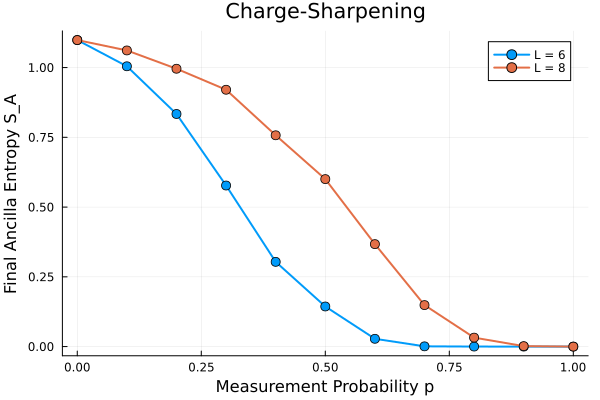

Plot displayed.


In [7]:
using LinearAlgebra
using Random
using StatsBase
using Statistics
using Plots
using Printf

# ==========================================
# 1. PHYSICS HELPER FUNCTIONS
# ==========================================

function initial_entangled_state_ghz(L::Int)
    @assert L >= 2 "System size must be at least 2"
    
    # State matrix: (System_Dim, Ancilla_Dim=3)
    psi_total = zeros(ComplexF64, 3^L, 3)
    
    # Branch 1: |00...00>_S ⊗ |0>_A  (Column 1)
    # Integer value of 000...0 in base 3 is 0
    idx_1 = 0
    psi_total[idx_1 + 1, 1] = 1.0 / sqrt(3)
    
    # Branch 2: |↑↑...↑↑>_S ⊗ |↑>_A  (Column 2)
    # Integer value of 111...1 in base 3 is (3^L - 1) / 2
    idx_2 = div(3^L - 1, 2)
    psi_total[idx_2 + 1, 2] = 1.0 / sqrt(3)
    
    # Branch 3: |↓↓...↓↓>_S ⊗ |↓>_A  (Column 3)
    # Integer value of 222...2 in base 3 is 3^L - 1
    idx_3 = 3^L - 1
    psi_total[idx_3 + 1, 3] = 1.0 / sqrt(3)
    
    return psi_total
end

function construct_gate()
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    # Block diagonal structure
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

# Apply Gate (Handles Matrix State)
function apply_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site-1)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_t = permutedims(reshape(psi_col, dL, 3, 3, dR), (2, 3, 1, 4))
        psi_new = U * reshape(psi_t, 9, :)
        psi[:, a] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
    end
end

# Apply PBC Boundary Gate
function apply_boundary_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, L::Int)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_reshaped = reshape(psi_col, 3, 3^(L-2), 3)
        psi_perm = permutedims(psi_reshaped, (3, 1, 2)) # (L, 1, Middle)
        psi_mat = reshape(psi_perm, 9, :)
        psi_new_mat = U * psi_mat
        psi_new_tensor = reshape(psi_new_mat, 3, 3, :)
        psi_final = permutedims(psi_new_tensor, (2, 3, 1)) # (1, Middle, L)
        psi[:, a] = reshape(psi_final, :)
    end
end

# Measurement (Sums probabilities across Ancilla branches)
function measure_site!(psi::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site)
    probs = zeros(Float64, 3)
    
    # 1. Sum probabilities from all 3 branches
    for a in 1:3
        psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
        for s in 1:3
            probs[s] += sum(abs2, psi_view[:, s, :])
        end
    end
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        # 2. Collapse all branches consistently
        for a in 1:3
            psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
            for s in 1:3
                if s != outcome
                    psi_view[:, s, :] .= 0
                else
                    psi_view[:, s, :] .*= norm_fac
                end
            end
        end
    end
end

# Ancilla Entropy
function ancilla_entropy(psi::Matrix{ComplexF64})
    rho_A = psi' * psi 
    evals = eigen(Hermitian(rho_A)).values
    evals = max.(evals, 1e-20)
    evals ./= sum(evals)
    return -sum(p -> p * log(p), evals)
end

# ==========================================
# 2. SIMULATION LOGIC
# ==========================================

function run_single_realization(L, p)
    # 1. Initialize GHZ-like Entangled State
    psi_total = initial_entangled_state_ghz(L)
    
    """
    # ==========================================
    # PHASE 1: Scrambling (No Measurements)
    # ==========================================
    for t in 1:L
        # Even Layer (1,2), (3,4), ...
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer (2,3), (4,5), ...
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary (L, 1)
        apply_boundary_gate!(psi_total, construct_gate(), L)
    end
    """
    
    # ==========================================
    # PHASE 2: Dynamics (With Measurements)
    # ==========================================
    for t in 1:L
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary
        apply_boundary_gate!(psi_total, construct_gate(), L)

        # Measurements
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(psi_total, l, L)
                end
            end
        end
    end
    
    return ancilla_entropy(psi_total)
end

function run_experiment_sweep()
    # --- PARAMETERS ---
    L_values = [6, 8]              
    p_values = 0.0:0.1:1.0         
    n_realizations = 500 
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation (GHZ Initialization + Two-Phase Evolution)...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        print("Simulating L = $L ")
        avg_entropies = Float64[]
        
        for p in p_values
            batch_entropies = zeros(Float64, n_realizations)
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            push!(avg_entropies, mean(batch_entropies))
            print(".") 
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. EXECUTION & PLOTTING
# ==========================================

p_vals, data = run_experiment_sweep()

println("\nGenerating Plot...")

# Set up the base plot
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Final Ancilla Entropy S_A",
    title = "Charge-Sharpening",
    legend = :topright,
    grid = true
)

# Plot each system size with explicit circle markers
for L in sort(collect(keys(data)))
    entropies = data[L]
    plot!(plt, p_vals, entropies, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5, 
        lw = 2
    )
end

display(plt)
println("Plot displayed.")

Starting Simulation (GHZ Initialization + Two-Phase Evolution)...
Threads available: 1
Simulating L = 6 ........... Done.
Simulating L = 8 ........... Done.
Simulating L = 10 ........... Done.

Generating Plot...


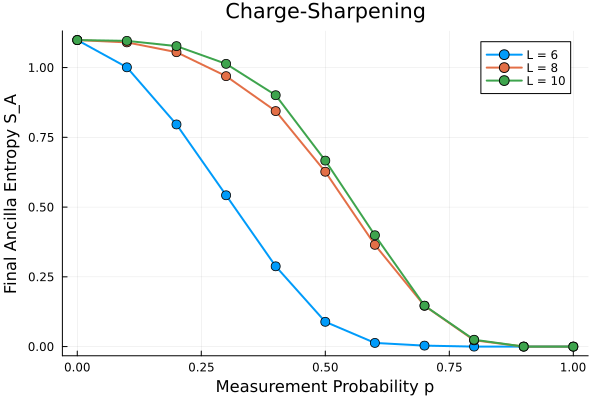

Plot displayed.


In [15]:
using LinearAlgebra
using Random
using StatsBase
using Statistics
using Plots
using Printf

# ==========================================
# 1. PHYSICS HELPER FUNCTIONS
# ==========================================

function initial_entangled_state_ghz(L::Int)
    @assert L >= 2 "System size must be at least 2"
    
    # State matrix: (System_Dim, Ancilla_Dim=3)
    psi_total = zeros(ComplexF64, 3^L, 3)
    
    # Branch 1: |00...00>_S ⊗ |0>_A  (Column 1)
    # Integer value of 000...0 in base 3 is 0
    idx_1 = 0
    psi_total[idx_1 + 1, 1] = 1.0 / sqrt(3)
    
    # Branch 2: |↑↑...↑↑>_S ⊗ |↑>_A  (Column 2)
    # Integer value of 111...1 in base 3 is (3^L - 1) / 2
    idx_2 = div(3^L - 1, 2)
    psi_total[idx_2 + 1, 2] = 1.0 / sqrt(3)
    
    # Branch 3: |↓↓...↓↓>_S ⊗ |↓>_A  (Column 3)
    # Integer value of 222...2 in base 3 is 3^L - 1
    idx_3 = 3^L - 1
    psi_total[idx_3 + 1, 3] = 1.0 / sqrt(3)
    
    return psi_total
end

function construct_gate()
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    # Block diagonal structure
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

# Apply Gate (Handles Matrix State)
function apply_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site-1)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_t = permutedims(reshape(psi_col, dL, 3, 3, dR), (2, 3, 1, 4))
        psi_new = U * reshape(psi_t, 9, :)
        psi[:, a] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
    end
end

# Apply PBC Boundary Gate
function apply_boundary_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, L::Int)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_reshaped = reshape(psi_col, 3, 3^(L-2), 3)
        psi_perm = permutedims(psi_reshaped, (3, 1, 2)) # (L, 1, Middle)
        psi_mat = reshape(psi_perm, 9, :)
        psi_new_mat = U * psi_mat
        psi_new_tensor = reshape(psi_new_mat, 3, 3, :)
        psi_final = permutedims(psi_new_tensor, (2, 3, 1)) # (1, Middle, L)
        psi[:, a] = reshape(psi_final, :)
    end
end

# Measurement (Sums probabilities across Ancilla branches)
function measure_site!(psi::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site)
    probs = zeros(Float64, 3)
    
    # 1. Sum probabilities from all 3 branches
    for a in 1:3
        psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
        for s in 1:3
            probs[s] += sum(abs2, psi_view[:, s, :])
        end
    end
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        # 2. Collapse all branches consistently
        for a in 1:3
            psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
            for s in 1:3
                if s != outcome
                    psi_view[:, s, :] .= 0
                else
                    psi_view[:, s, :] .*= norm_fac
                end
            end
        end
    end
end

# Ancilla Entropy
function ancilla_entropy(psi::Matrix{ComplexF64})
    rho_A = psi' * psi 
    evals = eigen(Hermitian(rho_A)).values
    evals = max.(evals, 1e-20)
    evals ./= sum(evals)
    return -sum(p -> p * log(p), evals)
end

# ==========================================
# 2. SIMULATION LOGIC
# ==========================================

function run_single_realization(L, p)
    # 1. Initialize GHZ-like Entangled State
    psi_total = initial_entangled_state_ghz(L)
    
    
    # ==========================================
    # PHASE 1: Scrambling (No Measurements)
    # ==========================================
    for t in 1:L
        # Even Layer (1,2), (3,4), ...
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer (2,3), (4,5), ...
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary (L, 1)
        #apply_boundary_gate!(psi_total, construct_gate(), L)
    end
    
    # ==========================================
    # PHASE 2: Dynamics (With Measurements)
    # ==========================================
    for t in 1:L
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary
        #apply_boundary_gate!(psi_total, construct_gate(), L)

        # Measurements
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(psi_total, l, L)
                end
            end
        end
    end
    
    return ancilla_entropy(psi_total)
end

function run_experiment_sweep()
    # --- PARAMETERS ---
    L_values = [6, 8, 10]              
    p_values = 0.0:0.1:1.0         
    n_realizations = 500 
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation (GHZ Initialization + Two-Phase Evolution)...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        print("Simulating L = $L ")
        avg_entropies = Float64[]
        
        for p in p_values
            batch_entropies = zeros(Float64, n_realizations)
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            push!(avg_entropies, mean(batch_entropies))
            print(".") 
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. EXECUTION & PLOTTING
# ==========================================

p_vals, data = run_experiment_sweep()

println("\nGenerating Plot...")

# Set up the base plot
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Final Ancilla Entropy S_A",
    title = "Charge-Sharpening",
    legend = :topright,
    grid = true
)

# Plot each system size with explicit circle markers
for L in sort(collect(keys(data)))
    entropies = data[L]
    plot!(plt, p_vals, entropies, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5, 
        lw = 2
    )
end

display(plt)
println("Plot displayed.")

Starting Simulation (GHZ Initialization + Two-Phase Evolution)...
Threads available: 1
Simulating L = 8 ..................... Done.
Simulating L = 10 ..................... Done.

Generating Plot...


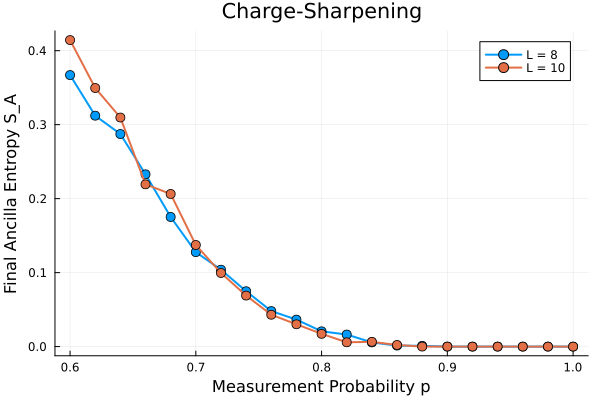

Plot displayed.


In [16]:
using LinearAlgebra
using Random
using StatsBase
using Statistics
using Plots
using Printf

# ==========================================
# 1. PHYSICS HELPER FUNCTIONS
# ==========================================

function initial_entangled_state_ghz(L::Int)
    @assert L >= 2 "System size must be at least 2"
    
    # State matrix: (System_Dim, Ancilla_Dim=3)
    psi_total = zeros(ComplexF64, 3^L, 3)
    
    # Branch 1: |00...00>_S ⊗ |0>_A  (Column 1)
    # Integer value of 000...0 in base 3 is 0
    idx_1 = 0
    psi_total[idx_1 + 1, 1] = 1.0 / sqrt(3)
    
    # Branch 2: |↑↑...↑↑>_S ⊗ |↑>_A  (Column 2)
    # Integer value of 111...1 in base 3 is (3^L - 1) / 2
    idx_2 = div(3^L - 1, 2)
    psi_total[idx_2 + 1, 2] = 1.0 / sqrt(3)
    
    # Branch 3: |↓↓...↓↓>_S ⊗ |↓>_A  (Column 3)
    # Integer value of 222...2 in base 3 is 3^L - 1
    idx_3 = 3^L - 1
    psi_total[idx_3 + 1, 3] = 1.0 / sqrt(3)
    
    return psi_total
end

function construct_gate()
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    # Block diagonal structure
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

# Apply Gate (Handles Matrix State)
function apply_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site-1)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_t = permutedims(reshape(psi_col, dL, 3, 3, dR), (2, 3, 1, 4))
        psi_new = U * reshape(psi_t, 9, :)
        psi[:, a] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
    end
end

# Apply PBC Boundary Gate
function apply_boundary_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, L::Int)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_reshaped = reshape(psi_col, 3, 3^(L-2), 3)
        psi_perm = permutedims(psi_reshaped, (3, 1, 2)) # (L, 1, Middle)
        psi_mat = reshape(psi_perm, 9, :)
        psi_new_mat = U * psi_mat
        psi_new_tensor = reshape(psi_new_mat, 3, 3, :)
        psi_final = permutedims(psi_new_tensor, (2, 3, 1)) # (1, Middle, L)
        psi[:, a] = reshape(psi_final, :)
    end
end

# Measurement (Sums probabilities across Ancilla branches)
function measure_site!(psi::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site)
    probs = zeros(Float64, 3)
    
    # 1. Sum probabilities from all 3 branches
    for a in 1:3
        psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
        for s in 1:3
            probs[s] += sum(abs2, psi_view[:, s, :])
        end
    end
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        # 2. Collapse all branches consistently
        for a in 1:3
            psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
            for s in 1:3
                if s != outcome
                    psi_view[:, s, :] .= 0
                else
                    psi_view[:, s, :] .*= norm_fac
                end
            end
        end
    end
end

# Ancilla Entropy
function ancilla_entropy(psi::Matrix{ComplexF64})
    rho_A = psi' * psi 
    evals = eigen(Hermitian(rho_A)).values
    evals = max.(evals, 1e-20)
    evals ./= sum(evals)
    return -sum(p -> p * log(p), evals)
end

# ==========================================
# 2. SIMULATION LOGIC
# ==========================================

function run_single_realization(L, p)
    # 1. Initialize GHZ-like Entangled State
    psi_total = initial_entangled_state_ghz(L)
    
    
    # ==========================================
    # PHASE 1: Scrambling (No Measurements)
    # ==========================================
    for t in 1:L
        # Even Layer (1,2), (3,4), ...
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer (2,3), (4,5), ...
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary (L, 1)
        #apply_boundary_gate!(psi_total, construct_gate(), L)
    end
    
    # ==========================================
    # PHASE 2: Dynamics (With Measurements)
    # ==========================================
    for t in 1:L
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary
        #apply_boundary_gate!(psi_total, construct_gate(), L)

        # Measurements
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(psi_total, l, L)
                end
            end
        end
    end
    
    return ancilla_entropy(psi_total)
end

function run_experiment_sweep()
    # --- PARAMETERS ---
    L_values = [8, 10]              
    p_values = range(0.6, stop=1.0, length=21)         
    n_realizations = 500 
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation (GHZ Initialization + Two-Phase Evolution)...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        print("Simulating L = $L ")
        avg_entropies = Float64[]
        
        for p in p_values
            batch_entropies = zeros(Float64, n_realizations)
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            push!(avg_entropies, mean(batch_entropies))
            print(".") 
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. EXECUTION & PLOTTING
# ==========================================

p_vals, data = run_experiment_sweep()

println("\nGenerating Plot...")

# Set up the base plot
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Final Ancilla Entropy S_A",
    title = "Charge-Sharpening",
    legend = :topright,
    grid = true
)

# Plot each system size with explicit circle markers
for L in sort(collect(keys(data)))
    entropies = data[L]
    plot!(plt, p_vals, entropies, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5, 
        lw = 2
    )
end

display(plt)
println("Plot displayed.")

Starting Simulation (GHZ Initialization + Two-Phase Evolution)...
Threads available: 1
Simulating L = 8 ..................... Done.
Simulating L = 10 ..................... Done.

Generating Plot...


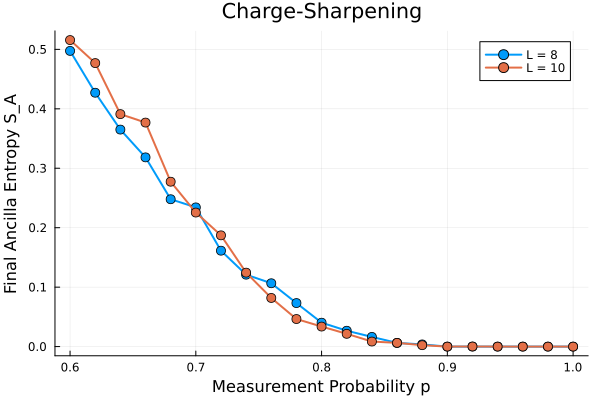

Plot displayed.


In [17]:
using LinearAlgebra
using Random
using StatsBase
using Statistics
using Plots
using Printf

# ==========================================
# 1. PHYSICS HELPER FUNCTIONS
# ==========================================

function initial_entangled_state_ghz(L::Int)
    @assert L >= 2 "System size must be at least 2"
    
    # State matrix: (System_Dim, Ancilla_Dim=3)
    psi_total = zeros(ComplexF64, 3^L, 3)
    
    # Branch 1: |00...00>_S ⊗ |0>_A  (Column 1)
    # Integer value of 000...0 in base 3 is 0
    idx_1 = 0
    psi_total[idx_1 + 1, 1] = 1.0 / sqrt(3)
    
    # Branch 2: |↑↑...↑↑>_S ⊗ |↑>_A  (Column 2)
    # Integer value of 111...1 in base 3 is (3^L - 1) / 2
    idx_2 = div(3^L - 1, 2)
    psi_total[idx_2 + 1, 2] = 1.0 / sqrt(3)
    
    # Branch 3: |↓↓...↓↓>_S ⊗ |↓>_A  (Column 3)
    # Integer value of 222...2 in base 3 is 3^L - 1
    idx_3 = 3^L - 1
    psi_total[idx_3 + 1, 3] = 1.0 / sqrt(3)
    
    return psi_total
end

function construct_gate()
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    # Block diagonal structure
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

# Apply Gate (Handles Matrix State)
function apply_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site-1)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_t = permutedims(reshape(psi_col, dL, 3, 3, dR), (2, 3, 1, 4))
        psi_new = U * reshape(psi_t, 9, :)
        psi[:, a] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
    end
end

# Apply PBC Boundary Gate
function apply_boundary_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, L::Int)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_reshaped = reshape(psi_col, 3, 3^(L-2), 3)
        psi_perm = permutedims(psi_reshaped, (3, 1, 2)) # (L, 1, Middle)
        psi_mat = reshape(psi_perm, 9, :)
        psi_new_mat = U * psi_mat
        psi_new_tensor = reshape(psi_new_mat, 3, 3, :)
        psi_final = permutedims(psi_new_tensor, (2, 3, 1)) # (1, Middle, L)
        psi[:, a] = reshape(psi_final, :)
    end
end

# Measurement (Sums probabilities across Ancilla branches)
function measure_site!(psi::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site)
    probs = zeros(Float64, 3)
    
    # 1. Sum probabilities from all 3 branches
    for a in 1:3
        psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
        for s in 1:3
            probs[s] += sum(abs2, psi_view[:, s, :])
        end
    end
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        # 2. Collapse all branches consistently
        for a in 1:3
            psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
            for s in 1:3
                if s != outcome
                    psi_view[:, s, :] .= 0
                else
                    psi_view[:, s, :] .*= norm_fac
                end
            end
        end
    end
end

# Ancilla Entropy
function ancilla_entropy(psi::Matrix{ComplexF64})
    rho_A = psi' * psi 
    evals = eigen(Hermitian(rho_A)).values
    evals = max.(evals, 1e-20)
    evals ./= sum(evals)
    return -sum(p -> p * log(p), evals)
end

# ==========================================
# 2. SIMULATION LOGIC
# ==========================================

function run_single_realization(L, p)
    # 1. Initialize GHZ-like Entangled State
    psi_total = initial_entangled_state_ghz(L)
    
    
    # ==========================================
    # PHASE 1: Scrambling (No Measurements)
    # ==========================================
    for t in 1:L
        # Even Layer (1,2), (3,4), ...
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer (2,3), (4,5), ...
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary (L, 1)
        apply_boundary_gate!(psi_total, construct_gate(), L)
    end
    
    # ==========================================
    # PHASE 2: Dynamics (With Measurements)
    # ==========================================
    for t in 1:L
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary
        apply_boundary_gate!(psi_total, construct_gate(), L)

        # Measurements
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(psi_total, l, L)
                end
            end
        end
    end
    
    return ancilla_entropy(psi_total)
end

function run_experiment_sweep()
    # --- PARAMETERS ---
    L_values = [8, 10]              
    p_values = range(0.6, stop=1.0, length=21)         
    n_realizations = 500 
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation (GHZ Initialization + Two-Phase Evolution)...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        print("Simulating L = $L ")
        avg_entropies = Float64[]
        
        for p in p_values
            batch_entropies = zeros(Float64, n_realizations)
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            push!(avg_entropies, mean(batch_entropies))
            print(".") 
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. EXECUTION & PLOTTING
# ==========================================

p_vals, data = run_experiment_sweep()

println("\nGenerating Plot...")

# Set up the base plot
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Final Ancilla Entropy S_A",
    title = "Charge-Sharpening",
    legend = :topright,
    grid = true
)

# Plot each system size with explicit circle markers
for L in sort(collect(keys(data)))
    entropies = data[L]
    plot!(plt, p_vals, entropies, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5, 
        lw = 2
    )
end

display(plt)
println("Plot displayed.")

Starting Simulation (Time Evolution Tracking)...
Threads available: 1
Simulating L = 8, p = 0.0  Done.
Simulating L = 8, p = 0.1  Done.
Simulating L = 8, p = 0.2  Done.
Simulating L = 8, p = 0.3  Done.
Simulating L = 8, p = 0.4  Done.
Simulating L = 8, p = 0.5  Done.
Simulating L = 8, p = 0.6  Done.
Simulating L = 8, p = 0.7  Done.
Simulating L = 8, p = 0.8  Done.
Simulating L = 8, p = 0.9  Done.
Simulating L = 8, p = 1.0  Done.

Generating Plot...


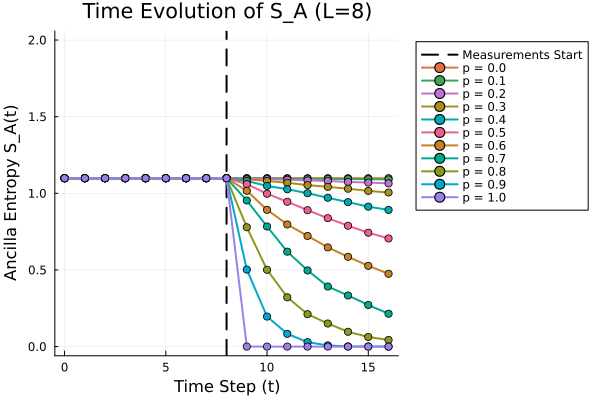

Plot displayed.


In [10]:
# ==========================================
# 2. SIMULATION LOGIC
# ==========================================

function run_single_realization(L, p)
    # 1. Initialize GHZ-like Entangled State
    psi_total = initial_entangled_state_ghz(L)
    
    # Array to track entropy over time
    entropy_ts = Float64[]
    push!(entropy_ts, ancilla_entropy(psi_total)) # t = 0
    
    # ==========================================
    # PHASE 1: Scrambling (No Measurements)
    # ==========================================
    for t in 1:L
        # Even Layer (1,2), (3,4), ...
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer (2,3), (4,5), ...
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary (L, 1)
        apply_boundary_gate!(psi_total, construct_gate(), L)
        
        # Record entropy
        push!(entropy_ts, ancilla_entropy(psi_total))
    end
    
    # ==========================================
    # PHASE 2: Dynamics (With Measurements)
    # ==========================================
    for t in 1:L
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary
        apply_boundary_gate!(psi_total, construct_gate(), L)

        # Measurements
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(psi_total, l, L)
                end
            end
        end
        
        # Record entropy
        push!(entropy_ts, ancilla_entropy(psi_total))
    end
    
    return entropy_ts
end

function run_experiment_sweep()
    # --- PARAMETERS ---
    # Fix L=8 for a clean time evolution plot. You can add more L's if desired.
    L_values = [8]              
    # Subset of p values so the plot isn't overly cluttered
    p_values = 0.0:0.1:1.0         
    n_realizations = 500 
    
    # Store results as Dict: (L, p) => Vector of averaged entropies over time
    results = Dict{Tuple{Int, Float64}, Vector{Float64}}()

    println("Starting Simulation (Time Evolution Tracking)...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        for p in p_values
            print("Simulating L = $L, p = $p ")
            
            # Pre-allocate array of arrays for thread safety
            batch_entropies = Vector{Vector{Float64}}(undef, n_realizations)
            
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            
            # Average the time series across all realizations
            avg_ts = zeros(Float64, 2 * L + 1)
            for ts in batch_entropies
                avg_ts .+= ts
            end
            avg_ts ./= n_realizations
            
            results[(L, p)] = avg_ts
            println(" Done.")
        end
    end

    return results
end

# ==========================================
# 3. EXECUTION & PLOTTING
# ==========================================

data = run_experiment_sweep()

println("\nGenerating Plot...")

# We will plot for L=8
L_plot = 8
times = 0:(2 * L_plot)

# Set up the base plot
plt = plot(
    xlabel = "Time Step (t)",
    ylabel = "Ancilla Entropy S_A(t)",
    title = "Time Evolution of S_A (L=$L_plot)",
    legend = :outertopright,
    grid = true
)

# Add a vertical line to indicate when measurements begin
vline!(plt, [L_plot], line=(:dash, :black, 2), label="Measurements Start")

# Sort the keys to ensure legend is ordered by p
sorted_keys = sort([k for k in keys(data) if k[1] == L_plot], by = x -> x[2])

for (L, p) in sorted_keys
    entropies_ts = data[(L, p)]
    plot!(plt, times, entropies_ts, 
        label = "p = $(@sprintf("%.1f", p))", 
        marker = :circle, 
        markersize = 4, 
        lw = 2
    )
end

display(plt)
println("Plot displayed.")

In [11]:
function half_cut_entropy(psi::Matrix{ComplexF64}, L::Int)
    # Define Region A as the first half of the chain
    L_A = div(L, 2)
    dim_A = 3^L_A
    
    # Reshape the state vector to (Dim_A, Dim_B * Dim_Ancilla)
    # Since Site 1 varies fastest, the first dim_A elements perfectly map to Region A.
    psi_mat = reshape(psi, dim_A, :)
    
    # Trace out Region B and the Ancilla to get Reduced Density Matrix for A
    rho_A = psi_mat * psi_mat' 
    
    # Calculate Von Neumann Entropy
    evals = eigen(Hermitian(rho_A)).values
    evals = max.(evals, 1e-20) # Avoid log(0)
    evals ./= sum(evals)
    
    return -sum(p -> p * log(p), evals)
end

half_cut_entropy (generic function with 1 method)

In [12]:
# ==========================================
# 2. SIMULATION LOGIC
# ==========================================

function run_single_realization(L, p)
    psi_total = initial_entangled_state_ghz(L)
    
    # Arrays to track both entropies over time
    ancilla_ts = Float64[]
    halfcut_ts = Float64[]
    
    push!(ancilla_ts, ancilla_entropy(psi_total))
    push!(halfcut_ts, half_cut_entropy(psi_total, L))
    
    # PHASE 1: Scrambling
    for t in 1:L
        for x in 1:2:(L-1); apply_gate!(psi_total, construct_gate(), x, L); end
        for x in 2:2:(L-2); apply_gate!(psi_total, construct_gate(), x, L); end
        apply_boundary_gate!(psi_total, construct_gate(), L)
        
        push!(ancilla_ts, ancilla_entropy(psi_total))
        push!(halfcut_ts, half_cut_entropy(psi_total, L))
    end
    
    # PHASE 2: Dynamics (With Measurements)
    for t in 1:L
        for x in 1:2:(L-1); apply_gate!(psi_total, construct_gate(), x, L); end
        for x in 2:2:(L-2); apply_gate!(psi_total, construct_gate(), x, L); end
        apply_boundary_gate!(psi_total, construct_gate(), L)

        if p > 0
            for l in 1:L
                if rand() < p; measure_site!(psi_total, l, L); end
            end
        end
        
        push!(ancilla_ts, ancilla_entropy(psi_total))
        push!(halfcut_ts, half_cut_entropy(psi_total, L))
    end
    
    return ancilla_ts, halfcut_ts
end

function run_experiment_sweep()
    L_values = [8]              
    p_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]         
    n_realizations = 250 
    
    # Dictionaries to store both time series
    results_anc = Dict{Tuple{Int, Float64}, Vector{Float64}}()
    results_half = Dict{Tuple{Int, Float64}, Vector{Float64}}()

    println("Starting Simulation (Tracking Ancilla & Half-Cut Entropy)...")

    for L in L_values
        for p in p_values
            print("Simulating L = $L, p = $p ")
            
            batch_anc = Vector{Vector{Float64}}(undef, n_realizations)
            batch_half = Vector{Vector{Float64}}(undef, n_realizations)
            
            Threads.@threads for i in 1:n_realizations
                anc, half = run_single_realization(L, p)
                batch_anc[i] = anc
                batch_half[i] = half
            end
            
            # Average the time series
            avg_anc = mean(batch_anc)
            avg_half = mean(batch_half)
            
            results_anc[(L, p)] = avg_anc
            results_half[(L, p)] = avg_half
            println(" Done.")
        end
    end

    return results_anc, results_half
end

run_experiment_sweep (generic function with 1 method)

Starting Simulation (Tracking Ancilla & Half-Cut Entropy)...
Simulating L = 8, p = 0.0  Done.
Simulating L = 8, p = 0.2  Done.
Simulating L = 8, p = 0.4  Done.
Simulating L = 8, p = 0.6  Done.
Simulating L = 8, p = 0.8  Done.
Simulating L = 8, p = 1.0  Done.

Generating Plots...


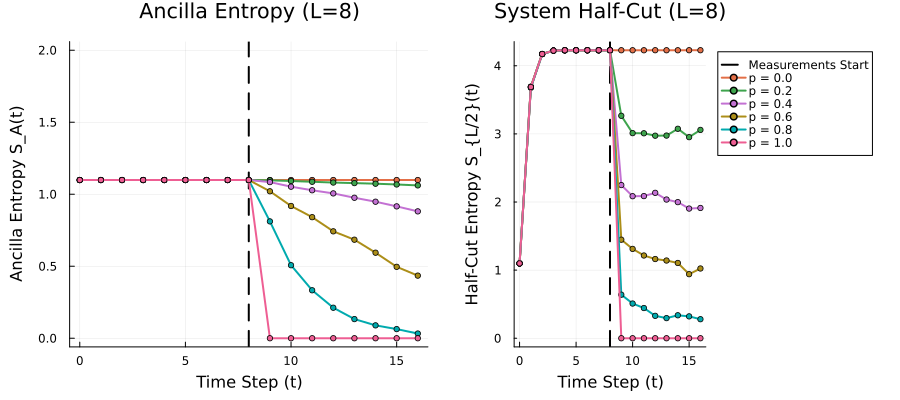

Plot displayed.


In [13]:
# ==========================================
# 3. EXECUTION & PLOTTING
# ==========================================

data_anc, data_half = run_experiment_sweep()

println("\nGenerating Plots...")

L_plot = 8
times = 0:(2 * L_plot)

# Set up the two subplots
plt_anc = plot(
    xlabel = "Time Step (t)", ylabel = "Ancilla Entropy S_A(t)",
    title = "Ancilla Entropy (L=$L_plot)",
    legend = false, grid = true
)

plt_half = plot(
    xlabel = "Time Step (t)", ylabel = "Half-Cut Entropy S_{L/2}(t)",
    title = "System Half-Cut (L=$L_plot)",
    legend = :outertopright, grid = true
)

# Add vertical lines for measurement start
vline!(plt_anc, [L_plot], line=(:dash, :black, 2))
vline!(plt_half, [L_plot], line=(:dash, :black, 2), label="Measurements Start")

sorted_keys = sort([k for k in keys(data_anc) if k[1] == L_plot], by = x -> x[2])

for (L, p) in sorted_keys
    p_label = "p = $(@sprintf("%.1f", p))"
    
    plot!(plt_anc, times, data_anc[(L, p)], marker = :circle, markersize = 3, lw = 2)
    plot!(plt_half, times, data_half[(L, p)], label = p_label, marker = :circle, markersize = 3, lw = 2)
end

# Combine into a 1x2 layout
final_plot = plot(plt_anc, plt_half, layout = (1, 2), size=(900, 400), margin=5Plots.mm)

display(final_plot)
println("Plot displayed.")

In [19]:
include("z3-ancilla.jl")

"function main()\n    s = ArgParseSettings()\n    @add_arg_table! s begin\n        \"--L\"\n            arg_type = Int\n            required = true\n        \"--p\"\n            arg_type = Float64\n            required = true\n        \"--start_shot\"\n            arg_type = Int\n            requir" ⋯ 324 bytes ⋯ " indices must be positive integers\")\n    end\n    if end_shot < start_shot\n        error(\"end_shot (end_shot) must be >= start_shot (start_shot)\")\n    end\n\n    for T in [2.0*L]\n        for shot in start_shot:end_shot\n            Entropy_t(L, T, p, shot)\n        end\n    end\nend\n\nmain()\n"

In [22]:
Entropy_t(8, 8.0, 0.5, 0)

17-element Vector{Float64}:
 1.0986122886681096
 1.0986122886681096
 1.0986122886681098
 1.0986122886681096
 1.0986122886681096
 1.0986122886681096
 1.0986122886681098
 1.0986122886681098
 1.0986122886681096
 1.0958655640900785
 0.9436739613869609
 1.0505687580035261
 1.0591571170527994
 1.0315891985671832
 1.0489454696586402
 1.0397608193922014
 0.8657166176326019

In [1]:
function initial_entangled_state_direct(L::Int)
    @assert L >= 2 "System size must be at least 2"
    
    # State matrix: (System_Dim, Ancilla_Dim=3)
    psi_total = zeros(ComplexF64, 3^L, 3)
    
    # Branch 1: |00...00>_S ⊗ |0>_A  (Column 1)
    # All sites are 0, base-3 integer is 0.
    idx_1 = 0
    psi_total[idx_1 + 1, 1] = 1.0 / sqrt(3)
    
    # Branch 2: |00...↑↓>_S ⊗ |↑>_A  (Column 2)
    # ↑ (1) at L-1, ↓ (2) at L
    idx_2 = 1 * 3^(L-2) + 2 * 3^(L-1)
    psi_total[idx_2 + 1, 2] = 1.0 / sqrt(3)
    
    # Branch 3: |00...↓↑>_S ⊗ |↓>_A  (Column 3)
    # ↓ (2) at L-1, ↑ (1) at L
    idx_3 = 2 * 3^(L-2) + 1 * 3^(L-1)
    psi_total[idx_3 + 1, 3] = 1.0 / sqrt(3)
    
    return psi_total
end

initial_entangled_state_direct (generic function with 1 method)

Starting Simulation (GHZ Initialization + Two-Phase Evolution)...
Threads available: 1
Simulating L = 6 ........... Done.
Simulating L = 8 ........... Done.
Simulating L = 10 ........... Done.

Generating Plot...


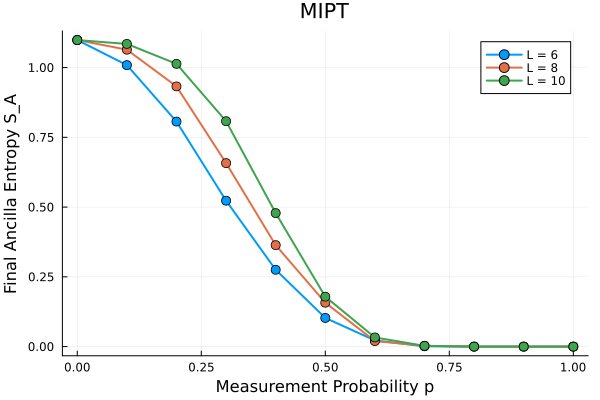

Plot displayed.


In [2]:
using LinearAlgebra
using Random
using StatsBase
using Statistics
using Plots
using Printf

# ==========================================
# 1. PHYSICS HELPER FUNCTIONS
# ==========================================

function initial_entangled_state_direct(L::Int)
    @assert L >= 2 "System size must be at least 2"
    
    # State matrix: (System_Dim, Ancilla_Dim=3)
    psi_total = zeros(ComplexF64, 3^L, 3)
    
    # Branch 1: |00...00>_S ⊗ |0>_A  (Column 1)
    # All sites are 0, base-3 integer is 0.
    idx_1 = 0
    psi_total[idx_1 + 1, 1] = 1.0 / sqrt(3)
    
    # Branch 2: |00...↑↓>_S ⊗ |↑>_A  (Column 2)
    # ↑ (1) at L-1, ↓ (2) at L
    idx_2 = 1 * 3^(L-2) + 2 * 3^(L-1)
    psi_total[idx_2 + 1, 2] = 1.0 / sqrt(3)
    
    # Branch 3: |00...↓↑>_S ⊗ |↓>_A  (Column 3)
    # ↓ (2) at L-1, ↑ (1) at L
    idx_3 = 2 * 3^(L-2) + 1 * 3^(L-1)
    psi_total[idx_3 + 1, 3] = 1.0 / sqrt(3)
    
    return psi_total
end

function initial_entangled_state_ghz(L::Int)
    @assert L >= 2 "System size must be at least 2"
    
    # State matrix: (System_Dim, Ancilla_Dim=3)
    psi_total = zeros(ComplexF64, 3^L, 3)
    
    # Branch 1: |00...00>_S ⊗ |0>_A  (Column 1)
    # Integer value of 000...0 in base 3 is 0
    idx_1 = 0
    psi_total[idx_1 + 1, 1] = 1.0 / sqrt(3)
    
    # Branch 2: |↑↑...↑↑>_S ⊗ |↑>_A  (Column 2)
    # Integer value of 111...1 in base 3 is (3^L - 1) / 2
    idx_2 = div(3^L - 1, 2)
    psi_total[idx_2 + 1, 2] = 1.0 / sqrt(3)
    
    # Branch 3: |↓↓...↓↓>_S ⊗ |↓>_A  (Column 3)
    # Integer value of 222...2 in base 3 is 3^L - 1
    idx_3 = 3^L - 1
    psi_total[idx_3 + 1, 3] = 1.0 / sqrt(3)
    
    return psi_total
end

function construct_gate()
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    # Block diagonal structure
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

# Apply Gate (Handles Matrix State)
function apply_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site-1)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_t = permutedims(reshape(psi_col, dL, 3, 3, dR), (2, 3, 1, 4))
        psi_new = U * reshape(psi_t, 9, :)
        psi[:, a] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
    end
end

# Apply PBC Boundary Gate
function apply_boundary_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, L::Int)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_reshaped = reshape(psi_col, 3, 3^(L-2), 3)
        psi_perm = permutedims(psi_reshaped, (3, 1, 2)) # (L, 1, Middle)
        psi_mat = reshape(psi_perm, 9, :)
        psi_new_mat = U * psi_mat
        psi_new_tensor = reshape(psi_new_mat, 3, 3, :)
        psi_final = permutedims(psi_new_tensor, (2, 3, 1)) # (1, Middle, L)
        psi[:, a] = reshape(psi_final, :)
    end
end

# Measurement (Sums probabilities across Ancilla branches)
function measure_site!(psi::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site)
    probs = zeros(Float64, 3)
    
    # 1. Sum probabilities from all 3 branches
    for a in 1:3
        psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
        for s in 1:3
            probs[s] += sum(abs2, psi_view[:, s, :])
        end
    end
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        # 2. Collapse all branches consistently
        for a in 1:3
            psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
            for s in 1:3
                if s != outcome
                    psi_view[:, s, :] .= 0
                else
                    psi_view[:, s, :] .*= norm_fac
                end
            end
        end
    end
end

# Ancilla Entropy
function ancilla_entropy(psi::Matrix{ComplexF64})
    rho_A = psi' * psi 
    evals = eigen(Hermitian(rho_A)).values
    evals = max.(evals, 1e-20)
    evals ./= sum(evals)
    return -sum(p -> p * log(p), evals)
end

# ==========================================
# 2. SIMULATION LOGIC
# ==========================================

function run_single_realization(L, p)
    # 1. Initialize GHZ-like Entangled State
    psi_total = initial_entangled_state_direct(L)
    
    
    # ==========================================
    # PHASE 1: Scrambling (No Measurements)
    # ==========================================
    for t in 1:L
        # Even Layer (1,2), (3,4), ...
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer (2,3), (4,5), ...
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary (L, 1)
        #apply_boundary_gate!(psi_total, construct_gate(), L)
    end
    
    # ==========================================
    # PHASE 2: Dynamics (With Measurements)
    # ==========================================
    for t in 1:L
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary
        #apply_boundary_gate!(psi_total, construct_gate(), L)

        # Measurements
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(psi_total, l, L)
                end
            end
        end
    end
    
    return ancilla_entropy(psi_total)
end

function run_experiment_sweep()
    # --- PARAMETERS ---
    L_values = [6, 8, 10]              
    p_values = 0.0:0.1:1.0         
    n_realizations = 500 
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation (GHZ Initialization + Two-Phase Evolution)...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        print("Simulating L = $L ")
        avg_entropies = Float64[]
        
        for p in p_values
            batch_entropies = zeros(Float64, n_realizations)
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            push!(avg_entropies, mean(batch_entropies))
            print(".") 
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. EXECUTION & PLOTTING
# ==========================================

p_vals, data = run_experiment_sweep()

println("\nGenerating Plot...")

# Set up the base plot
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Final Ancilla Entropy S_A",
    title = "MIPT",
    legend = :topright,
    grid = true
)

# Plot each system size with explicit circle markers
for L in sort(collect(keys(data)))
    entropies = data[L]
    plot!(plt, p_vals, entropies, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5, 
        lw = 2
    )
end

display(plt)
println("Plot displayed.")

Starting Simulation (GHZ Initialization + Two-Phase Evolution)...
Threads available: 1
Simulating L = 6 ........... Done.
Simulating L = 8 ........... Done.
Simulating L = 10 ........... Done.

Generating Plot...


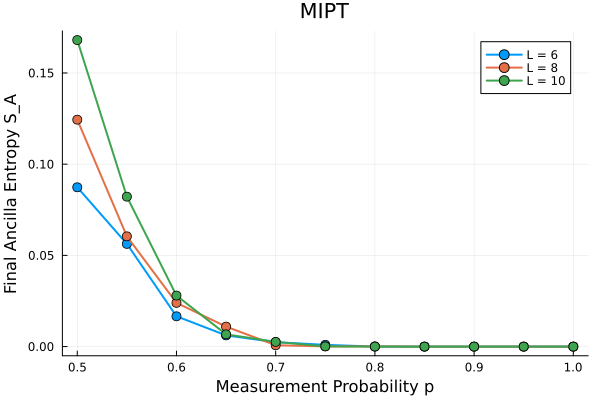

Plot displayed.


In [3]:
using LinearAlgebra
using Random
using StatsBase
using Statistics
using Plots
using Printf

# ==========================================
# 1. PHYSICS HELPER FUNCTIONS
# ==========================================

function initial_entangled_state_direct(L::Int)
    @assert L >= 2 "System size must be at least 2"
    
    # State matrix: (System_Dim, Ancilla_Dim=3)
    psi_total = zeros(ComplexF64, 3^L, 3)
    
    # Branch 1: |00...00>_S ⊗ |0>_A  (Column 1)
    # All sites are 0, base-3 integer is 0.
    idx_1 = 0
    psi_total[idx_1 + 1, 1] = 1.0 / sqrt(3)
    
    # Branch 2: |00...↑↓>_S ⊗ |↑>_A  (Column 2)
    # ↑ (1) at L-1, ↓ (2) at L
    idx_2 = 1 * 3^(L-2) + 2 * 3^(L-1)
    psi_total[idx_2 + 1, 2] = 1.0 / sqrt(3)
    
    # Branch 3: |00...↓↑>_S ⊗ |↓>_A  (Column 3)
    # ↓ (2) at L-1, ↑ (1) at L
    idx_3 = 2 * 3^(L-2) + 1 * 3^(L-1)
    psi_total[idx_3 + 1, 3] = 1.0 / sqrt(3)
    
    return psi_total
end

function initial_entangled_state_ghz(L::Int)
    @assert L >= 2 "System size must be at least 2"
    
    # State matrix: (System_Dim, Ancilla_Dim=3)
    psi_total = zeros(ComplexF64, 3^L, 3)
    
    # Branch 1: |00...00>_S ⊗ |0>_A  (Column 1)
    # Integer value of 000...0 in base 3 is 0
    idx_1 = 0
    psi_total[idx_1 + 1, 1] = 1.0 / sqrt(3)
    
    # Branch 2: |↑↑...↑↑>_S ⊗ |↑>_A  (Column 2)
    # Integer value of 111...1 in base 3 is (3^L - 1) / 2
    idx_2 = div(3^L - 1, 2)
    psi_total[idx_2 + 1, 2] = 1.0 / sqrt(3)
    
    # Branch 3: |↓↓...↓↓>_S ⊗ |↓>_A  (Column 3)
    # Integer value of 222...2 in base 3 is 3^L - 1
    idx_3 = 3^L - 1
    psi_total[idx_3 + 1, 3] = 1.0 / sqrt(3)
    
    return psi_total
end

function construct_gate()
    function haar()
        Z = randn(ComplexF64, 3, 3)
        Q, R = qr(Z)
        return Q * Diagonal(diag(R) ./ abs.(diag(R)))
    end
    
    U = zeros(ComplexF64, 9, 9)
    # Block diagonal structure
    idx0 = [1, 6, 8]; idx1 = [2, 4, 9]; idx2 = [3, 5, 7]
    U[idx0, idx0] = haar(); U[idx1, idx1] = haar(); U[idx2, idx2] = haar()
    return U
end

# Apply Gate (Handles Matrix State)
function apply_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site-1)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_t = permutedims(reshape(psi_col, dL, 3, 3, dR), (2, 3, 1, 4))
        psi_new = U * reshape(psi_t, 9, :)
        psi[:, a] = reshape(permutedims(reshape(psi_new, 3, 3, dL, dR), (3, 1, 2, 4)), :)
    end
end

# Apply PBC Boundary Gate
function apply_boundary_gate!(psi::Matrix{ComplexF64}, U::Matrix{ComplexF64}, L::Int)
    for a in 1:3
        psi_col = @view psi[:, a]
        psi_reshaped = reshape(psi_col, 3, 3^(L-2), 3)
        psi_perm = permutedims(psi_reshaped, (3, 1, 2)) # (L, 1, Middle)
        psi_mat = reshape(psi_perm, 9, :)
        psi_new_mat = U * psi_mat
        psi_new_tensor = reshape(psi_new_mat, 3, 3, :)
        psi_final = permutedims(psi_new_tensor, (2, 3, 1)) # (1, Middle, L)
        psi[:, a] = reshape(psi_final, :)
    end
end

# Measurement (Sums probabilities across Ancilla branches)
function measure_site!(psi::Matrix{ComplexF64}, site::Int, L::Int)
    dL, dR = 3^(site-1), 3^(L-site)
    probs = zeros(Float64, 3)
    
    # 1. Sum probabilities from all 3 branches
    for a in 1:3
        psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
        for s in 1:3
            probs[s] += sum(abs2, psi_view[:, s, :])
        end
    end
    
    if sum(probs) > 1e-15
        outcome = sample(1:3, Weights(probs))
        norm_fac = 1.0 / sqrt(probs[outcome])
        
        # 2. Collapse all branches consistently
        for a in 1:3
            psi_view = reshape(@view(psi[:, a]), dL, 3, dR)
            for s in 1:3
                if s != outcome
                    psi_view[:, s, :] .= 0
                else
                    psi_view[:, s, :] .*= norm_fac
                end
            end
        end
    end
end

# Ancilla Entropy
function ancilla_entropy(psi::Matrix{ComplexF64})
    rho_A = psi' * psi 
    evals = eigen(Hermitian(rho_A)).values
    evals = max.(evals, 1e-20)
    evals ./= sum(evals)
    return -sum(p -> p * log(p), evals)
end

# ==========================================
# 2. SIMULATION LOGIC
# ==========================================

function run_single_realization(L, p)
    # 1. Initialize GHZ-like Entangled State
    psi_total = initial_entangled_state_direct(L)
    
    
    # ==========================================
    # PHASE 1: Scrambling (No Measurements)
    # ==========================================
    for t in 1:L
        # Even Layer (1,2), (3,4), ...
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer (2,3), (4,5), ...
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary (L, 1)
        #apply_boundary_gate!(psi_total, construct_gate(), L)
    end
    
    # ==========================================
    # PHASE 2: Dynamics (With Measurements)
    # ==========================================
    for t in 1:L
        # Even Layer
        for x in 1:2:(L-1)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # Odd Layer
        for x in 2:2:(L-2)
            apply_gate!(psi_total, construct_gate(), x, L)
        end
        # PBC Boundary
        #apply_boundary_gate!(psi_total, construct_gate(), L)

        # Measurements
        if p > 0
            for l in 1:L
                if rand() < p
                    measure_site!(psi_total, l, L)
                end
            end
        end
    end
    
    return ancilla_entropy(psi_total)
end

function run_experiment_sweep()
    # --- PARAMETERS ---
    L_values = [6, 8, 10]              
    p_values = 0.5:0.05:1.0         
    n_realizations = 500 
    
    results = Dict{Int, Vector{Float64}}()

    println("Starting Simulation (GHZ Initialization + Two-Phase Evolution)...")
    println("Threads available: ", Threads.nthreads())

    for L in L_values
        print("Simulating L = $L ")
        avg_entropies = Float64[]
        
        for p in p_values
            batch_entropies = zeros(Float64, n_realizations)
            Threads.@threads for i in 1:n_realizations
                batch_entropies[i] = run_single_realization(L, p)
            end
            push!(avg_entropies, mean(batch_entropies))
            print(".") 
        end
        println(" Done.")
        results[L] = avg_entropies
    end

    return p_values, results
end

# ==========================================
# 3. EXECUTION & PLOTTING
# ==========================================

p_vals, data = run_experiment_sweep()

println("\nGenerating Plot...")

# Set up the base plot
plt = plot(
    xlabel = "Measurement Probability p",
    ylabel = "Final Ancilla Entropy S_A",
    title = "MIPT",
    legend = :topright,
    grid = true
)

# Plot each system size with explicit circle markers
for L in sort(collect(keys(data)))
    entropies = data[L]
    plot!(plt, p_vals, entropies, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5, 
        lw = 2
    )
end

display(plt)
println("Plot displayed.")

In [ ]:
plot(
    xlabel = "Measurement Probability p",
    ylabel = "Final Ancilla Entropy S_A",
    title = "MIPT",
    legend = :topright,
    grid = true
)

### Calculating the charge-variance order parameter for charge-sharpening transition

In [1]:
include("z3-shannon-qnv.jl")

"function main()\n    s = ArgParseSettings()\n    @add_arg_table! s begin\n        \"--L\"\n            arg_type = Int\n            required = true\n        \"--p\"\n            arg_type = Float64\n            required = true\n        \"--start_shot\"\n            arg_type = Int\n            requir" ⋯ 294 bytes ⋯ "ndices must be positive integers\")\n    end\n    if end_shot < start_shot\n        error(\"end_shot (end_shot) must be >= start_shot (start_shot)\")\n    end\n\n    for T in [2.0*L]\n        for shot in start_shot:end_shot\n            ChargeVar_t(L, T, p, shot)\n        end\n    end\nend\n\nmain()\n"

Checked that the conserved charge for |11...11> indeed remains constant 

In [2]:
ChargeVar_t(8, 16.0, 0.0, 1)

17-element Vector{Float64}:
 0.6666666666666801
 0.6666666666666665
 0.6666666666666665
 0.6666666666666667
 0.6666666666666665
 0.6666666666666665
 0.6666666666666676
 0.6666666666666656
 0.6666666666666665
 0.6666666666666656
 0.6666666666666659
 0.666666666666667
 0.6666666666666665
 0.6666666666666672
 0.6666666666666665
 0.6666666666666663
 0.6666666666666663

In [3]:
  include("z3-shannon-qnv.jl")                                  
                                                                
  using Base.Threads                                            
  using Printf                                                  
                                                                
  Ls = [6, 8, 10]
  ps = collect(range(0.0, 1.0; length=21))
  n_shots = 500                                                 
   
  jobs = [(L, p, shot) for L in Ls for p in ps for shot in      
  1:n_shots]      
  println("Running ", length(jobs), " trajectories on ",
  nthreads(), " threads -> ", QNV_OUTDIR)                       
   
  t0 = time()                                                   
  done = Threads.Atomic{Int}(0)
  @threads for k in eachindex(jobs)                             
      L, p, shot = jobs[k]
      T = 2.0 * L                                               
      ChargeVar_t(L, T, p, shot)
      n = Threads.atomic_add!(done, 1) + 1                      
      if n % 100 == 0
          @printf("  %5d / %d done (%.1fs elapsed)\n", n,       
  length(jobs), time() - t0)                                    
      end
  end                                                           
  println("All done in ", round(time() - t0; digits=1), "s.")

Running 31500 trajectories on 1 threads -> z3-haar-qnv-2026-04-28
    100 / 31500 done (0.4s elapsed)
    200 / 31500 done (0.5s elapsed)
    300 / 31500 done (0.5s elapsed)
    400 / 31500 done (0.6s elapsed)
    500 / 31500 done (0.6s elapsed)
    600 / 31500 done (0.7s elapsed)
    700 / 31500 done (0.7s elapsed)
    800 / 31500 done (0.8s elapsed)
    900 / 31500 done (0.8s elapsed)
   1000 / 31500 done (0.9s elapsed)
   1100 / 31500 done (1.0s elapsed)
   1200 / 31500 done (1.0s elapsed)
   1300 / 31500 done (1.1s elapsed)
   1400 / 31500 done (1.1s elapsed)
   1500 / 31500 done (1.2s elapsed)
   1600 / 31500 done (1.2s elapsed)
   1700 / 31500 done (1.3s elapsed)
   1800 / 31500 done (1.3s elapsed)
   1900 / 31500 done (1.4s elapsed)
   2000 / 31500 done (1.4s elapsed)
   2100 / 31500 done (1.5s elapsed)
   2200 / 31500 done (1.5s elapsed)
   2300 / 31500 done (1.6s elapsed)
   2400 / 31500 done (1.7s elapsed)
   2500 / 31500 done (1.7s elapsed)
   2600 / 31500 done (1.8s elapsed

L= 6 p=0.00  N= 500  Var(Q)=0.6667 ± 0.0000
L= 6 p=0.05  N= 500  Var(Q)=0.6441 ± 0.0040
L= 6 p=0.10  N= 500  Var(Q)=0.5817 ± 0.0076
L= 6 p=0.15  N= 500  Var(Q)=0.5004 ± 0.0103
L= 6 p=0.20  N= 500  Var(Q)=0.3765 ± 0.0117
L= 6 p=0.25  N= 500  Var(Q)=0.2548 ± 0.0118
L= 6 p=0.30  N= 500  Var(Q)=0.1386 ± 0.0099
L= 6 p=0.35  N= 500  Var(Q)=0.0611 ± 0.0071
L= 6 p=0.40  N= 500  Var(Q)=0.0176 ± 0.0044
L= 6 p=0.45  N= 500  Var(Q)=0.0040 ± 0.0015
L= 6 p=0.50  N= 500  Var(Q)=0.0005 ± 0.0005
L= 6 p=0.55  N= 500  Var(Q)=0.0000 ± 0.0000
L= 6 p=0.60  N= 500  Var(Q)=-0.0000 ± 0.0000
L= 6 p=0.65  N= 500  Var(Q)=-0.0000 ± 0.0000
L= 6 p=0.70  N= 500  Var(Q)=-0.0000 ± 0.0000
L= 6 p=0.75  N= 500  Var(Q)=-0.0000 ± 0.0000
L= 6 p=0.80  N= 500  Var(Q)=-0.0000 ± 0.0000
L= 6 p=0.85  N= 500  Var(Q)=-0.0000 ± 0.0000
L= 6 p=0.90  N= 500  Var(Q)=-0.0000 ± 0.0000
L= 6 p=0.95  N= 500  Var(Q)=-0.0000 ± 0.0000
L= 6 p=1.00  N= 500  Var(Q)=-0.0000 ± 0.0000
L= 8 p=0.00  N= 500  Var(Q)=0.6667 ± 0.0000
L= 8 p=0.05  N= 500  Va

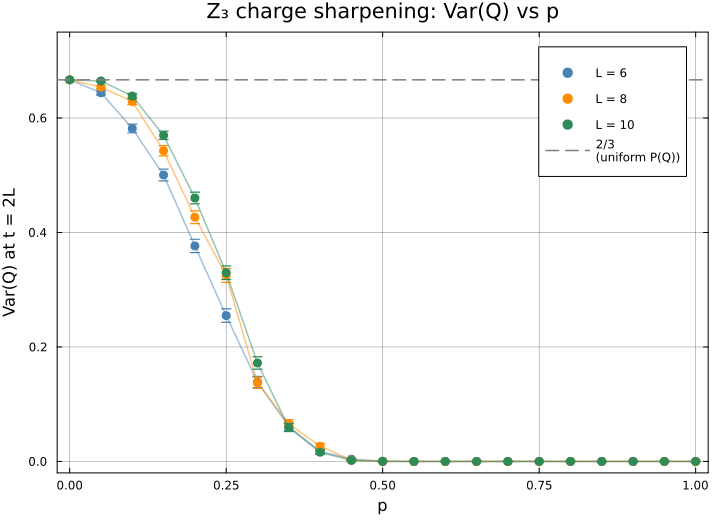

"/Users/dirac/Documents/z3-potts/src/z3-haar-qnv-2026-04-28/charge_variance_vs_p_errorbars_new.pdf"

In [5]:
using NPZ
using Statistics
using Glob
using Plots
using Printf

data_dir = QNV_OUTDIR  # or hard-code e.g.
"z3-haar-qnv-2026-04-28"

Ls = [6, 8, 10]
ps = collect(range(0.0, 1.0; length=21))

mean_final = fill(NaN, length(Ls), length(ps))
sem_final  = fill(NaN, length(Ls), length(ps))

for (i, L) in enumerate(Ls), (j, p) in enumerate(ps)
    T = 2.0 * L
    files = glob("L$(L),T$(T),p$(p),s*_qv.npy", data_dir)
    isempty(files) && (@warn "No files for L=$L, p=$p";
continue)
    finals = [npzread(f)[end] for f in files]
    mean_final[i, j] = mean(finals)
    sem_final[i, j]  = std(finals) / sqrt(length(finals))
    @printf("L=%2d p=%.2f  N=%4d  Var(Q)=%.4f ± %.4f\n",
            L, p, length(finals), mean_final[i,j],
sem_final[i,j])
end

colors = [:steelblue, :darkorange, :seagreen]

plt = plot(xlabel="p", ylabel="Var(Q) at t = 2L",
            title="Z₃ charge sharpening: Var(Q) vs p",
            legend=:topright, framestyle=:box,
            xlims=(-0.02, 1.02), ylims=(-0.02, 0.75),
            size=(720, 520), grid=true, gridalpha=0.25)

for (i, L) in enumerate(Ls)
    scatter!(plt, ps, mean_final[i, :];
            yerror = sem_final[i, :],
            label  = "L = $L",
            marker = :circle,
            markersize = 5,
            markerstrokewidth = 1.2,
            markerstrokecolor = :black,
            color  = colors[i],
            msc    = colors[i],
            linewidth = 0)
    plot!(plt, ps, mean_final[i, :];
        color = colors[i], lw = 1.5, alpha = 0.5, label =
"")
end

hline!(plt, [2/3]; ls=:dash, c=:gray, lw=1.5, label="2/3
(uniform P(Q))")

display(plt)
savefig(plt, joinpath(data_dir,
"charge_variance_vs_p_errorbars_new.pdf"))

### Runnings MIPT ancilla code for the modified setup

In [1]:
using Base.Threads
using Random

include("z3-ancilla.jl")

Ls     = [6, 8]
ps     = collect(range(0.0, 1.0, length=11))
shots  = 1:100

jobs = [(L, p, s) for L in Ls for p in ps for s in shots]
shuffle!(jobs)  # balance heavy (large L) work across threads

println("Running $(length(jobs)) jobs on $(nthreads()) threads -> $(DATA_DIR)")
flush(stdout)

done = Atomic{Int}(0)
total = length(jobs)

@threads for job in jobs
    L, p, s = job
    T = 1.0 * L^2
    Entropy_t(L, T, p, s)
    n = atomic_add!(done, 1) + 1
    if n % 100 == 0 || n == total
        @printf("[%5d/%5d] L=%d p=%.3f shot=%d (thread %d)\n",
                n, total, L, p, s, threadid())
        flush(stdout)
    end
end

println("Done. Data written to $(DATA_DIR)")

Running 2200 jobs on 1 threads -> z3-ancilla-mipt-data-2026-04-29
[  100/ 2200] L=8 p=0.500 shot=78 (thread 2)
[  200/ 2200] L=8 p=0.000 shot=97 (thread 2)
[  300/ 2200] L=6 p=0.900 shot=88 (thread 2)
[  400/ 2200] L=6 p=0.200 shot=79 (thread 2)
[  500/ 2200] L=6 p=0.500 shot=74 (thread 2)
[  600/ 2200] L=6 p=0.500 shot=81 (thread 2)
[  700/ 2200] L=8 p=0.000 shot=9 (thread 2)
[  800/ 2200] L=8 p=0.700 shot=16 (thread 2)
[  900/ 2200] L=6 p=0.100 shot=68 (thread 2)
[ 1000/ 2200] L=8 p=0.300 shot=7 (thread 2)
[ 1100/ 2200] L=8 p=0.800 shot=67 (thread 2)
[ 1200/ 2200] L=8 p=0.600 shot=77 (thread 2)
[ 1300/ 2200] L=6 p=0.000 shot=52 (thread 2)
[ 1400/ 2200] L=6 p=0.700 shot=66 (thread 2)
[ 1500/ 2200] L=8 p=0.600 shot=37 (thread 2)
[ 1600/ 2200] L=8 p=0.100 shot=71 (thread 2)
[ 1700/ 2200] L=6 p=1.000 shot=86 (thread 2)
[ 1800/ 2200] L=6 p=0.900 shot=99 (thread 2)
[ 1900/ 2200] L=8 p=0.000 shot=85 (thread 2)
[ 2000/ 2200] L=6 p=0.800 shot=11 (thread 2)
[ 2100/ 2200] L=8 p=0.100 shot=96 (t

L= 6 p=0.000 shots=100
L= 6 p=0.100 shots=100
L= 6 p=0.200 shots=100
L= 6 p=0.300 shots=100
L= 6 p=0.400 shots=100
L= 6 p=0.500 shots=100
L= 6 p=0.600 shots=100
L= 6 p=0.700 shots=100
L= 6 p=0.800 shots=100
L= 6 p=0.900 shots=100
L= 6 p=1.000 shots=100
L= 8 p=0.000 shots=100
L= 8 p=0.100 shots=100
L= 8 p=0.200 shots=100
L= 8 p=0.300 shots=100
L= 8 p=0.400 shots=100
L= 8 p=0.500 shots=100
L= 8 p=0.600 shots=100
L= 8 p=0.700 shots=100
L= 8 p=0.800 shots=100
L= 8 p=0.900 shots=100
L= 8 p=1.000 shots=100
Saved ../plots/ancilla_entropy_L2pL_vs_p.pdf


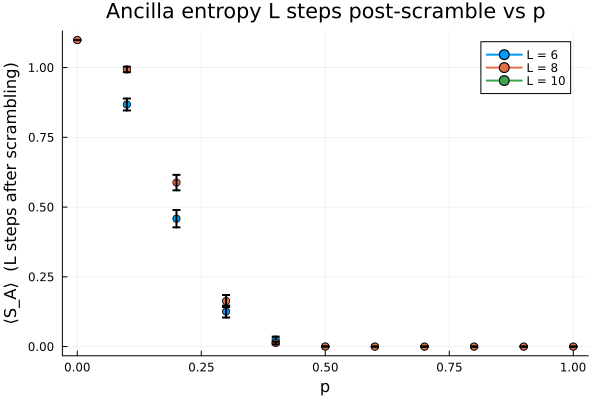

In [5]:
using NPZ
using Plots
using Statistics
using Printf
using Dates

# ---- config -----------------------------------------------------------------
data_dir = "z3-ancilla-mipt-data-$(Dates.format(Dates.today(), "yyyy-mm-dd"))"
# Or hard-code a previous run's folder, e.g.:
# data_dir = "z3-ancilla-mipt-data-2026-04-29"

Ls = [6, 8, 10]
ps = collect(range(0.0, 1.0, length=21))
# -----------------------------------------------------------------------------

# Filename pattern: L{L},T{T},p{p},s{shot}_a.npy
file_re = r"^L(\d+),T([\d\.]+),p([\d\.]+),s(\d+)_a\.npy$"

# Group files: (L, p) -> Vector{String}
groups = Dict{Tuple{Int,Float64}, Vector{String}}()
for f in readdir(data_dir)
    m = match(file_re, f)
    m === nothing && continue
    L  = parse(Int, m.captures[1])
    p  = parse(Float64, m.captures[3])
    push!(get!(groups, (L, p), String[]), joinpath(data_dir, f))
end

plt = plot(xlabel = "p",
           ylabel = "⟨S_A⟩  (L steps after scrambling)",
           title  = "Ancilla entropy L steps post-scramble vs p",
           legend = :topright,
           lw     = 2,
           marker = :circle)

for L in Ls
    idx = 2L + 1                        # L dynamics steps after scrambling (1-indexed)
    means = fill(NaN, length(ps))
    sems  = fill(NaN, length(ps))
    for (i, p) in enumerate(ps)
        files = get(groups, (L, p), String[])
        isempty(files) && continue
        vals = Float64[]
        for f in files
            data = npzread(f)
            idx <= length(data) && push!(vals, data[idx])
        end
        if !isempty(vals)
            means[i] = mean(vals)
            sems[i]  = length(vals) > 1 ? std(vals)/sqrt(length(vals)) : 0.0
        end
        @printf("L=%2d p=%.3f shots=%d\n", L, p, length(vals))
    end
    plot!(plt, ps, means;
          yerror      = sems,
          label       = "L = $L",
          seriestype  = :line,
          linewidth   = 2,
          markershape = :circle,
          markersize  = 4)
end

mkpath("../plots")
outfile = "../plots/ancilla_entropy_L2pL_vs_p.pdf"
savefig(plt, outfile)
println("Saved $outfile")
display(plt)



Processing System Size L = 6 ...
........... Done.

Processing System Size L = 8 ...
........... Done.

Processing System Size L = 10 ...
 Done.

Generating Summary Plot...


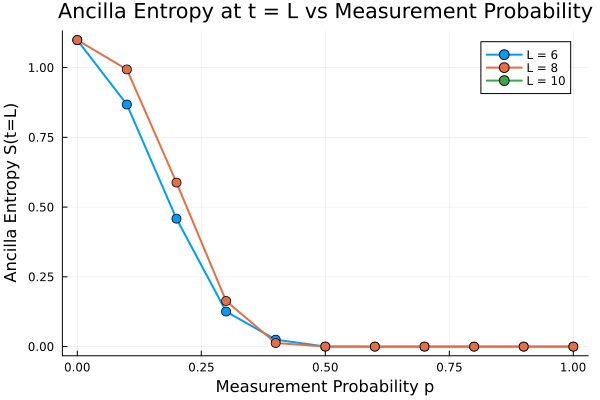

Plot saved as ../plots/Ancilla_at_t_equals_L_Summary_pm.pdf


In [8]:
using NPZ
using Statistics
using Plots
using Printf
using Dates

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "z3-ancilla-mipt-data-2026-04-29"
# Or hard-code a previous run's folder, e.g.:
# data_dir = "z3-ancilla-mipt-data-2026-04-29"

L_values  = [6, 8, 10]
num_shots = 500
p_values  = range(0.0, 1.0, length=21)

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")

    T  = 1.0 * L^2
    t = 2.0 * L
    dt = 1.0

    expected_length = Int(2 * t / dt) + 1     # 1 + L scramble + 2L dynamics  (matches 3L+1 only when T=L; here SE_list length is 3L+1)
    target_index    = 2L + 1                  # L dynamics steps after scrambling

    se_at_t_equals_L = Float64[]

    for p in p_values
        p_clean = round(p, digits=4)
        p_str   = string(p_clean)

        accumulated_se = Float64[]
        count_valid    = 0

        for s in 1:num_shots
            fname = "L$(L),T$(T),p$(p_str),s$(s)_a.npy"
            fpath = joinpath(data_dir, fname)

            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    if isempty(accumulated_se)
                        accumulated_se = zeros(Float64, length(traj))
                    end
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end

        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            if length(avg_traj) >= target_index
                push!(se_at_t_equals_L, avg_traj[target_index])
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".")
        else
            push!(se_at_t_equals_L, NaN)
        end
    end

    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title  = "Ancilla Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Ancilla Entropy S(t=L)",
    legend = :topright,
    grid   = true,
    lw     = 2
)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    mask = .!isnan.(se_vals)
    plot!(plt_summary, p_vals[mask], se_vals[mask],
        label      = "L = $L",
        marker     = :circle,
        markersize = 5,
        lw         = 2
    )
end

display(plt_summary)
mkpath("../plots")
outfile = "../plots/Ancilla_at_t_equals_L_Summary_pm.pdf"
savefig(plt_summary, outfile)
println("Plot saved as $outfile")

In [26]:
using Base.Threads, Random, Printf                                                                 
                                                                                                     
include("z3-shannon.jl")   # defines Entropy_t and SHANNON_DATA_DIR                                
                                                                                                    
Ls    = [6, 8]                                                                                     
ps    = collect(range(0.3, 0.5, length=21))                                                        
shots = 1:5000                                                                                      
                                                                                                    
jobs = [(L, p, s) for L in Ls for p in ps for s in shots]                                          
shuffle!(jobs)   # mix heavy (large L) and light jobs across threads
                                                                                                    
println("Running $(length(jobs)) jobs on $(nthreads()) threads -> $(SHANNON_DATA_DIR)")            
flush(stdout)                                                                                      
                                                                                                    
done  = Atomic{Int}(0)                                                                             
total = length(jobs)
                                                                                                    
# wrap in @async so you can run a "stop" cell later if needed                                      
runner = @async @threads for job in jobs
    L, p, s = job                                                                                  
    T = 2.0 * L                                                                                    
    Entropy_t(L, T, p, s)
    n = atomic_add!(done, 1) + 1                                                                   
    if n % 100 == 0 || n == total                                                                  
        @printf("[%5d/%5d] L=%d p=%.3f shot=%d (thread %d)\n",
                n, total, L, p, s, threadid())                                                     
        flush(stdout)
    end                                                                                            
end

Running 210000 jobs on 1 threads -> z3-shannon-mipt-data-2026-04-29


Task (runnable, started) @0x000000013e8ac2e0

[  100/210000] L=6 p=0.330 shot=2958 (thread 2)
[  200/210000] L=8 p=0.460 shot=1940 (thread 2)
[  300/210000] L=8 p=0.300 shot=3307 (thread 2)
[  400/210000] L=8 p=0.330 shot=1856 (thread 2)
[  500/210000] L=8 p=0.400 shot=329 (thread 2)
[  600/210000] L=6 p=0.470 shot=1241 (thread 2)
[  700/210000] L=8 p=0.480 shot=3828 (thread 2)
[  800/210000] L=6 p=0.430 shot=4552 (thread 2)
[  900/210000] L=8 p=0.420 shot=721 (thread 2)
[ 1000/210000] L=6 p=0.370 shot=3252 (thread 2)
[ 1100/210000] L=8 p=0.480 shot=4710 (thread 2)
[ 1200/210000] L=6 p=0.400 shot=1301 (thread 2)
[ 1300/210000] L=6 p=0.460 shot=807 (thread 2)
[ 1400/210000] L=6 p=0.330 shot=1580 (thread 2)
[ 1500/210000] L=6 p=0.410 shot=2177 (thread 2)
[ 1600/210000] L=8 p=0.330 shot=1477 (thread 2)
[ 1700/210000] L=6 p=0.320 shot=3010 (thread 2)
[ 1800/210000] L=8 p=0.430 shot=1522 (thread 2)
[ 1900/210000] L=6 p=0.350 shot=682 (thread 2)
[ 2000/210000] L=8 p=0.470 shot=208 (thread 2)
[ 2100/210000] L=6 p=0.460 shot=4655 (thread 


Processing System Size L = 6 ...
..................... Done.

Processing System Size L = 8 ...
..................... Done.

Generating Summary Plot...


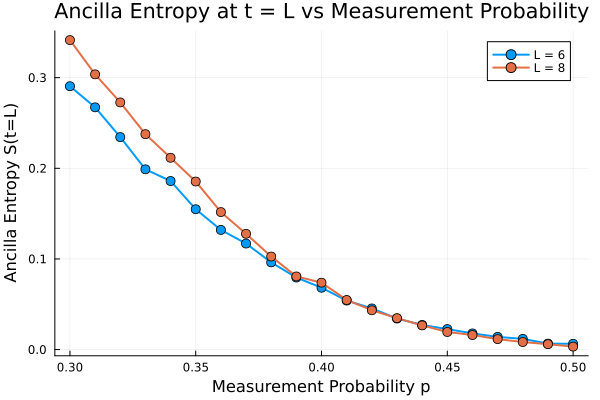

Plot saved as ../plots/Ancilla_at_t_equals_L_Summary_pm1.pdf


In [ ]:
using NPZ
using Statistics
using Plots
using Printf
using Dates

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "z3-shannon-mipt-data-2026-04-29"
# Or hard-code a previous run's folder, e.g.:
# data_dir = "z3-ancilla-mipt-data-2026-04-29"

L_values  = [6, 8]
num_shots = 5000
p_values  = range(0.3, 0.5, length=21)

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")

    T  = 2.0 * L
    dt = 1.0

    expected_length = Int(2 * T / dt) + 1     # 1 + L scramble + 2L dynamics  (matches 3L+1 only when T=L; here SE_list length is 3L+1)
    target_index    = 2L + 1                  # L dynamics steps after scrambling

    se_at_t_equals_L = Float64[]

    for p in p_values
        p_clean = round(p, digits=4)
        p_str   = string(p_clean)

        accumulated_se = Float64[]
        count_valid    = 0

        for s in 1:num_shots
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)

            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    if isempty(accumulated_se)
                        accumulated_se = zeros(Float64, length(traj))
                    end
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end

        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            if length(avg_traj) >= target_index
                push!(se_at_t_equals_L, avg_traj[target_index])
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".")
        else
            push!(se_at_t_equals_L, NaN)
        end
    end

    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title  = "Ancilla Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Ancilla Entropy S(t=L)",
    legend = :topright,
    grid   = true,
    lw     = 2
)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    mask = .!isnan.(se_vals)
    plot!(plt_summary, p_vals[mask], se_vals[mask],
        label      = "L = $L",
        marker     = :circle,
        markersize = 5,
        lw         = 2
    )
end

display(plt_summary)
mkpath("../plots")
outfile = "../plots/Ancilla_at_t_equals_L_Summary_pm1.pdf"
savefig(plt_summary, outfile)
println("Plot saved as $outfile")